# Proyek Akhir: Menyelesaikan Permasalahan Jaya Jaya Institut

- Nama: Ulum Al Hikam
- Email: hkmfile@gmail.com
- Id Dicoding: ulum_al_hikam

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Menyiapkan data yang akan diguankan

In [2]:
url = "https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/bce7a57a496d083716138922bc5839b5c30fa4ea/students_performance/data.csv"

df = pd.read_csv(url, sep=";")

df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

In [3]:
df.shape

(4424, 37)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   int64  
 10 

### Interpretasi

Berdasarkan hasil pemeriksaan awal menggunakan `df.shape` dan `df.info()`, dataset memiliki **4.424 baris dan 37 kolom**. Hal ini menunjukkan bahwa dataset menyediakan informasi yang cukup beragam mengenai mahasiswa untuk digunakan dalam proses analisis dan pemodelan.

Dari 37 kolom yang tersedia, terdapat **29 kolom bertipe integer (`int64`)**, **7 kolom bertipe float (`float64`)**, dan **1 kolom bertipe string (`str`)**. Kolom `Status` merupakan kolom bertipe string yang menjadi target dalam proyek ini, dengan kategori status mahasiswa seperti `Dropout`, `Enrolled`, dan `Graduate`.

Kolom-kolom pada dataset mencakup berbagai informasi mengenai mahasiswa, seperti karakteristik pribadi, informasi pendaftaran, kondisi finansial, serta performa akademik. Informasi tersebut dapat digunakan untuk mengetahui pola yang berkaitan dengan status pendidikan mahasiswa.

Pada hasil `df.info()`, kolom-kolom yang ditampilkan memiliki jumlah data non-null sebanyak 4.424. Namun, pemeriksaan missing value secara keseluruhan tetap perlu dilakukan menggunakan `df.isnull().sum()` untuk memastikan kondisi seluruh kolom dalam dataset.

In [5]:
df.isnull().sum()

Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollment                               0


### Interpretasi

Berdasarkan hasil pengecekan missing value menggunakan `df.isnull().sum()`, seluruh kolom pada dataset memiliki nilai missing sebesar **0**. Hal ini menunjukkan bahwa dari total **4.424 data mahasiswa**, tidak terdapat data yang kosong pada seluruh **37 kolom** yang tersedia.

Dengan demikian, dataset tidak memerlukan penanganan missing value seperti penghapusan baris maupun pengisian nilai yang hilang. Seluruh data dapat digunakan untuk tahap analisis dan persiapan data selanjutnya.

In [6]:
df.duplicated().sum()

np.int64(0)

### Interpretasi

Berdasarkan hasil pengecekan menggunakan `df.duplicated().sum()`, diperoleh nilai **0**. Hal ini menunjukkan bahwa tidak terdapat baris data yang terduplikasi pada dataset.

Dengan demikian, seluruh **4.424 data mahasiswa** dapat dianggap sebagai data yang unik berdasarkan kombinasi seluruh kolom yang tersedia. Tidak diperlukan proses penghapusan data duplikat pada tahap data preparation.

In [7]:
df['Status'].value_counts()

Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

### Interpretasi

Berdasarkan distribusi pada kolom `Status`, dari total **4.424 mahasiswa**, terdapat **2.209 mahasiswa** berstatus `Graduate`, **1.421 mahasiswa** berstatus `Dropout`, dan **794 mahasiswa** berstatus `Enrolled`.

Kategori `Graduate` merupakan status dengan jumlah mahasiswa terbanyak, sedangkan `Enrolled` memiliki jumlah mahasiswa paling sedikit. Sementara itu, jumlah mahasiswa yang mengalami `Dropout` mencapai **1.421 mahasiswa**, sehingga dropout merupakan salah satu kondisi yang cukup besar dalam dataset dan sesuai dengan permasalahan bisnis yang ingin dianalisis.

Distribusi target menunjukkan bahwa ketiga kelas memiliki jumlah data yang berbeda. Oleh karena itu, kondisi distribusi kelas perlu diperhatikan pada tahap pemodelan karena target yang digunakan merupakan **multiclass classification** dengan tiga kategori, yaitu `Graduate`, `Dropout`, dan `Enrolled`.

In [8]:
df.nunique().sort_values()

Daytime_evening_attendance                        2
Displaced                                         2
Debtor                                            2
Educational_special_needs                         2
International                                     2
Scholarship_holder                                2
Gender                                            2
Tuition_fees_up_to_date                           2
Status                                            3
Marital_status                                    6
Application_order                                 8
Inflation_rate                                    9
Curricular_units_2nd_sem_without_evaluations     10
Unemployment_rate                                10
GDP                                              10
Curricular_units_1st_sem_without_evaluations     11
Course                                           17
Previous_qualification                           17
Application_mode                                 18
Curricular_u

### Interpretasi

Berdasarkan hasil pengecekan jumlah nilai unik menggunakan `df.nunique().sort_values()`, setiap kolom memiliki jumlah nilai unik yang berbeda. Beberapa kolom memiliki hanya **2 nilai unik**, seperti `Displaced`, `Debtor`, `Educational_special_needs`, `International`, `Scholarship_holder`, `Gender`, dan `Tuition_fees_up_to_date`. Kolom-kolom tersebut menunjukkan karakteristik atau kondisi mahasiswa yang bersifat biner.

Kolom `Status` memiliki **3 nilai unik**, yaitu `Graduate`, `Dropout`, dan `Enrolled`. Hal ini mengonfirmasi bahwa variabel target pada proyek ini merupakan permasalahan **multiclass classification** dengan tiga kategori.

Beberapa kolom lainnya memiliki jumlah nilai unik yang relatif sedikit, seperti `Marital_status`, `Application_order`, `Course`, `Previous_qualification`, dan `Application_mode`, sehingga perlu diperhatikan sebagai variabel kategorikal pada tahap analisis dan preprocessing.

Sementara itu, kolom seperti `Previous_qualification_grade`, `Admission_grade`, `Curricular_units_1st_sem_grade`, dan `Curricular_units_2nd_sem_grade` memiliki jumlah nilai unik yang lebih banyak sehingga lebih sesuai untuk dianalisis sebagai variabel numerikal.

Hasil ini menunjukkan bahwa dataset memiliki kombinasi variabel kategorikal dan numerikal. Identifikasi tipe variabel tersebut akan digunakan sebagai dasar dalam proses Exploratory Data Analysis dan data preparation pada tahap berikutnya.

In [9]:
categorical_columns = [
    'Marital_status',
    'Application_mode',
    'Application_order',
    'Course',
    'Daytime_evening_attendance',
    'Previous_qualification',
    'Nacionality',
    'Mothers_qualification',
    'Fathers_qualification',
    'Mothers_occupation',
    'Fathers_occupation',
    'Displaced',
    'Educational_special_needs',
    'Debtor',
    'Tuition_fees_up_to_date',
    'Gender',
    'Scholarship_holder',
    'International',
    'Status'
]

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].value_counts())


Marital_status:
Marital_status
1    3919
2     379
4      91
5      25
6       6
3       4
Name: count, dtype: int64

Application_mode:
Application_mode
1     1708
17     872
39     785
43     312
44     213
7      139
18     124
42      77
51      59
16      38
53      35
15      30
5       16
10      10
2        3
57       1
26       1
27       1
Name: count, dtype: int64

Application_order:
Application_order
1    3026
2     547
3     309
4     249
5     154
6     137
9       1
0       1
Name: count, dtype: int64

Course:
Course
9500    766
9147    380
9238    355
9085    337
9773    331
9991    268
9670    268
9254    252
9070    226
171     215
8014    215
9003    210
9853    192
9119    170
9130    141
9556     86
33       12
Name: count, dtype: int64

Daytime_evening_attendance:
Daytime_evening_attendance
1    3941
0     483
Name: count, dtype: int64

Previous_qualification:
Previous_qualification
1     3717
39     219
19     162
3      126
12      45
40      40
42      36
2    

### Interpretasi

Berdasarkan hasil pemeriksaan nilai unik pada variabel kategorikal, terdapat beberapa variabel yang menggunakan kode numerik untuk merepresentasikan kategori. Oleh karena itu, nilai numerik pada beberapa kolom tidak dapat langsung dianggap sebagai nilai kontinu atau memiliki hubungan matematis antar kategori.

Variabel `Marital_status` memiliki 6 kategori, sedangkan `Application_mode` memiliki 18 kategori dan `Application_order` memiliki 8 kategori. Variabel `Course` dan `Previous_qualification` masing-masing memiliki 17 kategori. Hal ini menunjukkan adanya variasi karakteristik mahasiswa berdasarkan informasi pendaftaran dan latar belakang pendidikan sebelumnya.

Pada variabel kondisi mahasiswa, terdapat beberapa variabel dengan dua kategori, seperti `Daytime_evening_attendance`, `Displaced`, `Educational_special_needs`, `Debtor`, `Tuition_fees_up_to_date`, `Gender`, `Scholarship_holder`, dan `International`. Variabel-variabel tersebut memiliki dua nilai yang digunakan untuk membedakan kondisi atau karakteristik tertentu pada mahasiswa.

Variabel `Nacionality`, `Mothers_qualification`, `Fathers_qualification`, `Mothers_occupation`, dan `Fathers_occupation` memiliki jumlah kategori yang lebih beragam. Hal ini menunjukkan adanya variasi latar belakang mahasiswa dan kondisi keluarga yang dapat dipertimbangkan dalam analisis.

Pada variabel target `Status`, terdapat tiga kategori, yaitu `Graduate` sebanyak 2.209 mahasiswa, `Dropout` sebanyak 1.421 mahasiswa, dan `Enrolled` sebanyak 794 mahasiswa. Distribusi tersebut menunjukkan bahwa dataset memiliki tiga kelas target dengan jumlah data yang berbeda.

Hasil pemeriksaan ini menjadi dasar untuk membedakan variabel kategorikal dan numerikal pada tahap Exploratory Data Analysis dan Data Preparation. Kode numerik pada variabel kategorikal tidak akan diperlakukan sebagai nilai kontinu hanya berdasarkan tipe datanya.


In [10]:
df.describe()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


### Interpretasi

Berdasarkan hasil statistik deskriptif menggunakan `df.describe()`, seluruh variabel numerik memiliki jumlah data (`count`) sebanyak **4.424**, sesuai dengan jumlah baris pada dataset. Hal ini menunjukkan bahwa tidak terdapat data kosong pada variabel yang ditampilkan.

Beberapa variabel pada dataset menggunakan angka sebagai kode kategori, seperti `Marital_status`, `Application_mode`, `Application_order`, `Course`, `Daytime_evening_attendance`, `Previous_qualification`, dan `Nacionality`. Oleh karena itu, nilai statistik seperti mean dan standar deviasi pada variabel-variabel tersebut tidak digunakan untuk menggambarkan ukuran numerik secara langsung.

Pada variabel akademik, terdapat beberapa informasi mengenai aktivitas mahasiswa pada semester pertama dan semester kedua. Sebagai contoh, `Curricular_units_1st_sem_enrolled` memiliki nilai maksimum 26, sedangkan `Curricular_units_2nd_sem_enrolled` memiliki nilai maksimum 23. Jumlah unit yang disetujui (`Curricular_units_1st_sem_approved` dan `Curricular_units_2nd_sem_approved`) masing-masing memiliki nilai maksimum 26 dan 20.

Variabel nilai akademik menunjukkan adanya variasi performa mahasiswa. `Curricular_units_1st_sem_grade` dan `Curricular_units_2nd_sem_grade` memiliki nilai minimum 0 dan maksimum sekitar **18,57**. Nilai median masing-masing sekitar **12,20**, yang menunjukkan adanya variasi nilai akademik antar mahasiswa.

Variabel `Previous_qualification_grade` memiliki nilai minimum **95** dan maksimum **190**, dengan median **133,10**. Sementara itu, `Admission_grade` memiliki nilai minimum **95** dan maksimum **190**. Kedua variabel tersebut menunjukkan adanya variasi nilai akademik mahasiswa sebelum dan pada saat proses penerimaan.

Variabel kondisi ekonomi makro juga memiliki variasi nilai. `Unemployment_rate` berada pada rentang **7,6 hingga 16,2**, `Inflation_rate` berada pada rentang **-0,8 hingga 3,7**, dan `GDP` berada pada rentang **-4,06 hingga 3,51**.

Secara keseluruhan, dataset memiliki kombinasi variabel kategorikal yang direpresentasikan menggunakan kode numerik dan variabel numerikal yang menggambarkan nilai atau jumlah. Identifikasi ini akan menjadi dasar dalam menentukan kelompok variabel pada tahap Exploratory Data Analysis, sehingga setiap variabel dapat dianalisis dengan metode yang sesuai.

In [11]:
for i, col in enumerate(df.columns):
    print(f"{i}. {col}")

0. Marital_status
1. Application_mode
2. Application_order
3. Course
4. Daytime_evening_attendance
5. Previous_qualification
6. Previous_qualification_grade
7. Nacionality
8. Mothers_qualification
9. Fathers_qualification
10. Mothers_occupation
11. Fathers_occupation
12. Admission_grade
13. Displaced
14. Educational_special_needs
15. Debtor
16. Tuition_fees_up_to_date
17. Gender
18. Scholarship_holder
19. Age_at_enrollment
20. International
21. Curricular_units_1st_sem_credited
22. Curricular_units_1st_sem_enrolled
23. Curricular_units_1st_sem_evaluations
24. Curricular_units_1st_sem_approved
25. Curricular_units_1st_sem_grade
26. Curricular_units_1st_sem_without_evaluations
27. Curricular_units_2nd_sem_credited
28. Curricular_units_2nd_sem_enrolled
29. Curricular_units_2nd_sem_evaluations
30. Curricular_units_2nd_sem_approved
31. Curricular_units_2nd_sem_grade
32. Curricular_units_2nd_sem_without_evaluations
33. Unemployment_rate
34. Inflation_rate
35. GDP
36. Status


### Interpretasi

Berdasarkan pemeriksaan nama kolom, dataset terdiri dari **37 kolom** yang mencakup informasi mengenai karakteristik mahasiswa, proses pendaftaran, kondisi mahasiswa, performa akademik, kondisi ekonomi, dan status akhir mahasiswa.

Secara umum, variabel pada dataset dapat dikelompokkan menjadi beberapa bagian.

1. **Informasi karakteristik dan latar belakang mahasiswa**
   
   Variabel yang termasuk dalam kelompok ini antara lain `Marital_status`, `Nacionality`, `Gender`, `Age_at_enrollment`, serta informasi pendidikan orang tua seperti `Mothers_qualification`, `Fathers_qualification`, `Mothers_occupation`, dan `Fathers_occupation`.

2. **Informasi pendaftaran mahasiswa**
   
   Kelompok ini mencakup `Application_mode`, `Application_order`, `Course`, `Daytime_evening_attendance`, `Previous_qualification`, `Previous_qualification_grade`, dan `Admission_grade`. Variabel tersebut memberikan informasi mengenai proses pendaftaran dan latar belakang pendidikan mahasiswa sebelum masuk ke institusi.

3. **Kondisi dan karakteristik mahasiswa**
   
   Variabel seperti `Displaced`, `Educational_special_needs`, `Debtor`, `Tuition_fees_up_to_date`, `Scholarship_holder`, dan `International` memberikan informasi mengenai kondisi dan karakteristik mahasiswa selama menjalani pendidikan.

4. **Performa akademik semester pertama**
   
   Dataset menyediakan informasi mengenai jumlah mata kuliah yang diambil, dievaluasi, disetujui, nilai akademik, serta jumlah mata kuliah tanpa evaluasi pada semester pertama. Variabel tersebut mencakup `Curricular_units_1st_sem_credited`, `Curricular_units_1st_sem_enrolled`, `Curricular_units_1st_sem_evaluations`, `Curricular_units_1st_sem_approved`, `Curricular_units_1st_sem_grade`, dan `Curricular_units_1st_sem_without_evaluations`.

5. **Performa akademik semester kedua**
   
   Informasi yang sama juga tersedia untuk semester kedua, yaitu `Curricular_units_2nd_sem_credited`, `Curricular_units_2nd_sem_enrolled`, `Curricular_units_2nd_sem_evaluations`, `Curricular_units_2nd_sem_approved`, `Curricular_units_2nd_sem_grade`, dan `Curricular_units_2nd_sem_without_evaluations`.

6. **Kondisi ekonomi**
   
   Dataset juga menyediakan variabel `Unemployment_rate`, `Inflation_rate`, dan `GDP` yang menggambarkan kondisi ekonomi pada periode pengamatan.

7. **Target**
   
   Kolom `Status` merupakan target yang digunakan dalam proyek ini. Target memiliki tiga kategori, yaitu `Graduate`, `Dropout`, dan `Enrolled`, sehingga permasalahan machine learning yang akan dibangun termasuk dalam multiclass classification.

Dari struktur tersebut terlihat bahwa dataset memiliki informasi akademik dari semester pertama dan semester kedua. Hal ini perlu diperhatikan pada tahap data preparation karena tujuan proyek adalah membantu institusi mendeteksi mahasiswa yang berpotensi mengalami dropout sedini mungkin. Penggunaan informasi akademik perlu disesuaikan dengan waktu prediksi agar model tidak menggunakan informasi yang belum tersedia pada saat prediksi dilakukan.


## Data Preparation / Preprocessing

In [14]:
target = 'Status'

X = df.drop('Status', axis=1)
y = df['Status']

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (4424, 36)
Shape y: (4424,)


### Interpretasi

Berdasarkan hasil pemisahan data, kolom `Status` ditetapkan sebagai variabel target (`y`), sedangkan seluruh 36 kolom lainnya digunakan sebagai variabel fitur (`X`).

Dataset memiliki **4.424 data mahasiswa**, sehingga `X` memiliki ukuran **(4.424, 36)** dan `y` memiliki ukuran **(4.424,)**. Hal ini menunjukkan bahwa setiap data mahasiswa memiliki 36 informasi yang dapat digunakan sebagai fitur untuk memprediksi satu status mahasiswa.

Variabel target `Status` memiliki tiga kategori, yaitu `Graduate`, `Dropout`, dan `Enrolled`. Oleh karena itu, permasalahan yang akan diselesaikan merupakan **multiclass classification** dengan tiga kelas target.

Pada tahap ini belum dilakukan perubahan terhadap data, seperti encoding, scaling, maupun penghapusan fitur. Proses tersebut akan dilakukan setelah fitur yang relevan untuk pemodelan ditentukan.

In [15]:
print("Jumlah fitur:", X.shape[1])

for i, col in enumerate(X.columns):
    print(f"{i}. {col}")

Jumlah fitur: 36
0. Marital_status
1. Application_mode
2. Application_order
3. Course
4. Daytime_evening_attendance
5. Previous_qualification
6. Previous_qualification_grade
7. Nacionality
8. Mothers_qualification
9. Fathers_qualification
10. Mothers_occupation
11. Fathers_occupation
12. Admission_grade
13. Displaced
14. Educational_special_needs
15. Debtor
16. Tuition_fees_up_to_date
17. Gender
18. Scholarship_holder
19. Age_at_enrollment
20. International
21. Curricular_units_1st_sem_credited
22. Curricular_units_1st_sem_enrolled
23. Curricular_units_1st_sem_evaluations
24. Curricular_units_1st_sem_approved
25. Curricular_units_1st_sem_grade
26. Curricular_units_1st_sem_without_evaluations
27. Curricular_units_2nd_sem_credited
28. Curricular_units_2nd_sem_enrolled
29. Curricular_units_2nd_sem_evaluations
30. Curricular_units_2nd_sem_approved
31. Curricular_units_2nd_sem_grade
32. Curricular_units_2nd_sem_without_evaluations
33. Unemployment_rate
34. Inflation_rate
35. GDP


In [16]:
features = [
    'Marital_status',
    'Application_mode',
    'Application_order',
    'Course',
    'Daytime_evening_attendance',
    'Previous_qualification',
    'Previous_qualification_grade',
    'Nacionality',
    'Mothers_qualification',
    'Fathers_qualification',
    'Mothers_occupation',
    'Fathers_occupation',
    'Admission_grade',
    'Displaced',
    'Educational_special_needs',
    'Debtor',
    'Tuition_fees_up_to_date',
    'Gender',
    'Scholarship_holder',
    'Age_at_enrollment',
    'International',
    'Curricular_units_1st_sem_credited',
    'Curricular_units_1st_sem_enrolled',
    'Curricular_units_1st_sem_evaluations',
    'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade',
    'Curricular_units_1st_sem_without_evaluations',
    'Unemployment_rate',
    'Inflation_rate',
    'GDP'
]

X = df[features]
y = df['Status']

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (4424, 30)
Shape y: (4424,)


### Interpretasi

Berdasarkan hasil pemisahan fitur dan target, dataset memiliki **4.424 data mahasiswa** dengan **30 fitur** yang digunakan sebagai variabel input (`X`), sedangkan `Status` digunakan sebagai variabel target (`y`).

Dengan demikian, `X` memiliki ukuran **(4.424, 30)**, yang berarti terdapat 4.424 mahasiswa dan 30 fitur untuk setiap mahasiswa. Sementara itu, `y` memiliki ukuran **(4.424,)** karena setiap mahasiswa memiliki satu nilai target `Status`.

Pada tahap ini, fitur semester kedua tidak digunakan agar model berfokus pada informasi yang tersedia hingga semester pertama. Dengan pendekatan tersebut, model nantinya dapat digunakan untuk membantu mengidentifikasi mahasiswa yang berpotensi mengalami dropout lebih awal.

Selanjutnya, data akan dipersiapkan untuk proses pemodelan melalui **pembagian data menjadi data training dan data testing**.

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Shape X_train:", X_train.shape)
print("Shape X_test :", X_test.shape)
print("Shape y_train:", y_train.shape)
print("Shape y_test :", y_test.shape)

Shape X_train: (3539, 30)
Shape X_test : (885, 30)
Shape y_train: (3539,)
Shape y_test : (885,)


### Interpretasi

Berdasarkan hasil pembagian data menggunakan `train_test_split`, sebanyak **80% data** digunakan sebagai data training dan **20% data** digunakan sebagai data testing.

Data training terdiri dari **3.539 data mahasiswa** dengan **30 fitur**, sedangkan data testing terdiri dari **885 data mahasiswa** dengan jumlah fitur yang sama, yaitu 30 fitur.

Variabel target `y_train` memiliki **3.539 data**, sementara `y_test` memiliki **885 data**. Jumlah tersebut sesuai dengan pembagian seluruh **4.424 data mahasiswa** pada dataset.

Parameter `stratify=y` digunakan agar proporsi masing-masing kategori pada `Status` tetap terjaga antara data training dan data testing. Dengan demikian, ketiga kategori target (`Graduate`, `Dropout`, dan `Enrolled`) tetap terwakili pada kedua kelompok data.

Selanjutnya, data akan masuk ke tahap **preprocessing**, yaitu memisahkan fitur berdasarkan jenis datanya dan melakukan transformasi yang diperlukan sebelum digunakan oleh model machine learning.

In [18]:
categorical_features = [
    'Marital_status',
    'Application_mode',
    'Application_order',
    'Course',
    'Daytime_evening_attendance',
    'Previous_qualification',
    'Nacionality',
    'Mothers_qualification',
    'Fathers_qualification',
    'Mothers_occupation',
    'Fathers_occupation',
    'Displaced',
    'Educational_special_needs',
    'Debtor',
    'Tuition_fees_up_to_date',
    'Gender',
    'Scholarship_holder',
    'International'
]

numerical_features = [
    'Previous_qualification_grade',
    'Admission_grade',
    'Age_at_enrollment',
    'Curricular_units_1st_sem_credited',
    'Curricular_units_1st_sem_enrolled',
    'Curricular_units_1st_sem_evaluations',
    'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade',
    'Curricular_units_1st_sem_without_evaluations',
    'Unemployment_rate',
    'Inflation_rate',
    'GDP'
]

print("Jumlah categorical features:", len(categorical_features))
print("Jumlah numerical features:", len(numerical_features))
print("Total features:", len(categorical_features) + len(numerical_features))

Jumlah categorical features: 18
Jumlah numerical features: 12
Total features: 30


### Interpretasi

Berdasarkan hasil pengelompokan fitur, dari total **30 fitur** yang digunakan dalam pemodelan terdapat **18 fitur kategorikal** dan **12 fitur numerik**.

Sebanyak 18 fitur kategorikal berisi informasi yang direpresentasikan dalam bentuk kode kategori, seperti `Marital_status`, `Course`, `Gender`, `Scholarship_holder`, dan beberapa karakteristik lainnya. Meskipun sebagian besar fitur tersebut memiliki tipe data integer, nilainya tidak diperlakukan sebagai angka kontinu.

Sementara itu, 12 fitur numerik berisi nilai yang memiliki makna kuantitatif, seperti `Age_at_enrollment`, `Admission_grade`, nilai akademik semester pertama, jumlah curricular units, serta indikator kondisi ekonomi seperti `Unemployment_rate`, `Inflation_rate`, dan `GDP`.

Jumlah seluruh fitur adalah **30**, sehingga seluruh fitur yang telah dipilih sebelumnya sudah terkelompok dan tidak ada fitur yang tertinggal dari proses preprocessing.

Selanjutnya, fitur kategorikal akan dilakukan **One-Hot Encoding**, sedangkan fitur numerik akan dilakukan **Standard Scaling** agar keduanya dapat diproses dengan baik oleh model machine learning.

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

print("Preprocessor berhasil dibuat.")

Preprocessor berhasil dibuat.


### Interpretasi

Berdasarkan hasil pembuatan preprocessing pipeline, `ColumnTransformer` berhasil dikonfigurasi untuk menangani dua jenis fitur yang telah ditentukan sebelumnya.

Fitur numerik akan diproses menggunakan `StandardScaler` untuk melakukan standardisasi skala data. Sementara itu, fitur kategorikal akan diproses menggunakan `OneHotEncoder` agar setiap kategori dapat direpresentasikan dalam bentuk numerik yang dapat digunakan oleh model machine learning.

Parameter `handle_unknown='ignore'` digunakan agar kategori baru yang mungkin muncul pada data testing tidak menyebabkan error ketika dilakukan proses transformasi.

Pada tahap ini, preprocessing baru berupa konfigurasi pipeline dan belum diterapkan pada data training maupun testing. Selanjutnya, preprocessing akan diterapkan pada data training dan data testing.

In [20]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Shape X_train setelah preprocessing:", X_train_processed.shape)
print("Shape X_test setelah preprocessing:", X_test_processed.shape)

Shape X_train setelah preprocessing: (3539, 245)
Shape X_test setelah preprocessing: (885, 245)


### Interpretasi

Setelah preprocessing diterapkan, jumlah fitur berubah dari **30 fitur awal menjadi 245 fitur**. Perubahan ini terjadi karena fitur kategorikal yang diproses menggunakan `OneHotEncoder` diubah menjadi beberapa kolom berdasarkan kategori yang terdapat pada data training.

Sementara itu, fitur numerik diproses menggunakan `StandardScaler` sehingga skala nilainya menjadi lebih seragam tanpa mengubah jumlah fiturnya.

Data training yang sebelumnya memiliki ukuran **(3.539, 30)** berubah menjadi **(3.539, 245)**, sedangkan data testing yang sebelumnya memiliki ukuran **(885, 30)** berubah menjadi **(885, 245)**.

Jumlah baris tetap sama karena preprocessing tidak menghapus data mahasiswa. Perubahan hanya terjadi pada jumlah kolom karena proses encoding fitur kategorikal.

Dengan demikian, data training dan testing telah berhasil dipersiapkan dalam bentuk numerik dan dapat digunakan pada tahap **Exploratory Data Analysis (EDA)** dan pemodelan machine learning.

## Exploratory Data Analysis

### Analisis Univariate

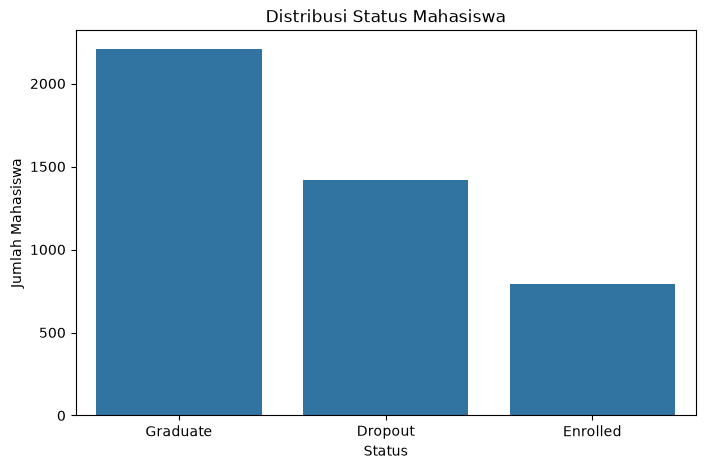

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Status',
    order=df['Status'].value_counts().index
)

plt.title('Distribusi Status Mahasiswa')
plt.xlabel('Status')
plt.ylabel('Jumlah Mahasiswa')
plt.show()

#### Interpretasi

Berdasarkan visualisasi distribusi `Status`, terlihat bahwa status mahasiswa terdiri dari tiga kategori, yaitu `Graduate`, `Dropout`, dan `Enrolled`.

Kategori `Graduate` memiliki jumlah mahasiswa paling banyak, yaitu **2.209 mahasiswa**. Selanjutnya, terdapat **1.421 mahasiswa** yang berstatus `Dropout`, sedangkan kategori `Enrolled` memiliki jumlah paling sedikit, yaitu **794 mahasiswa**.

Distribusi tersebut menunjukkan bahwa jumlah mahasiswa pada setiap kategori target tidak sama. Kategori `Graduate` memiliki proporsi sekitar **49,9%**, `Dropout` sekitar **32,1%**, dan `Enrolled` sekitar **18,0%** dari keseluruhan 4.424 mahasiswa.

Perbedaan jumlah antar kelas perlu diperhatikan pada tahap pemodelan karena target `Status` merupakan permasalahan **multiclass classification** dengan tiga kategori. Oleh karena itu, evaluasi model nantinya tidak hanya melihat akurasi, tetapi juga metrik lain seperti precision, recall, dan F1-score untuk melihat performa model pada masing-masing kelas.

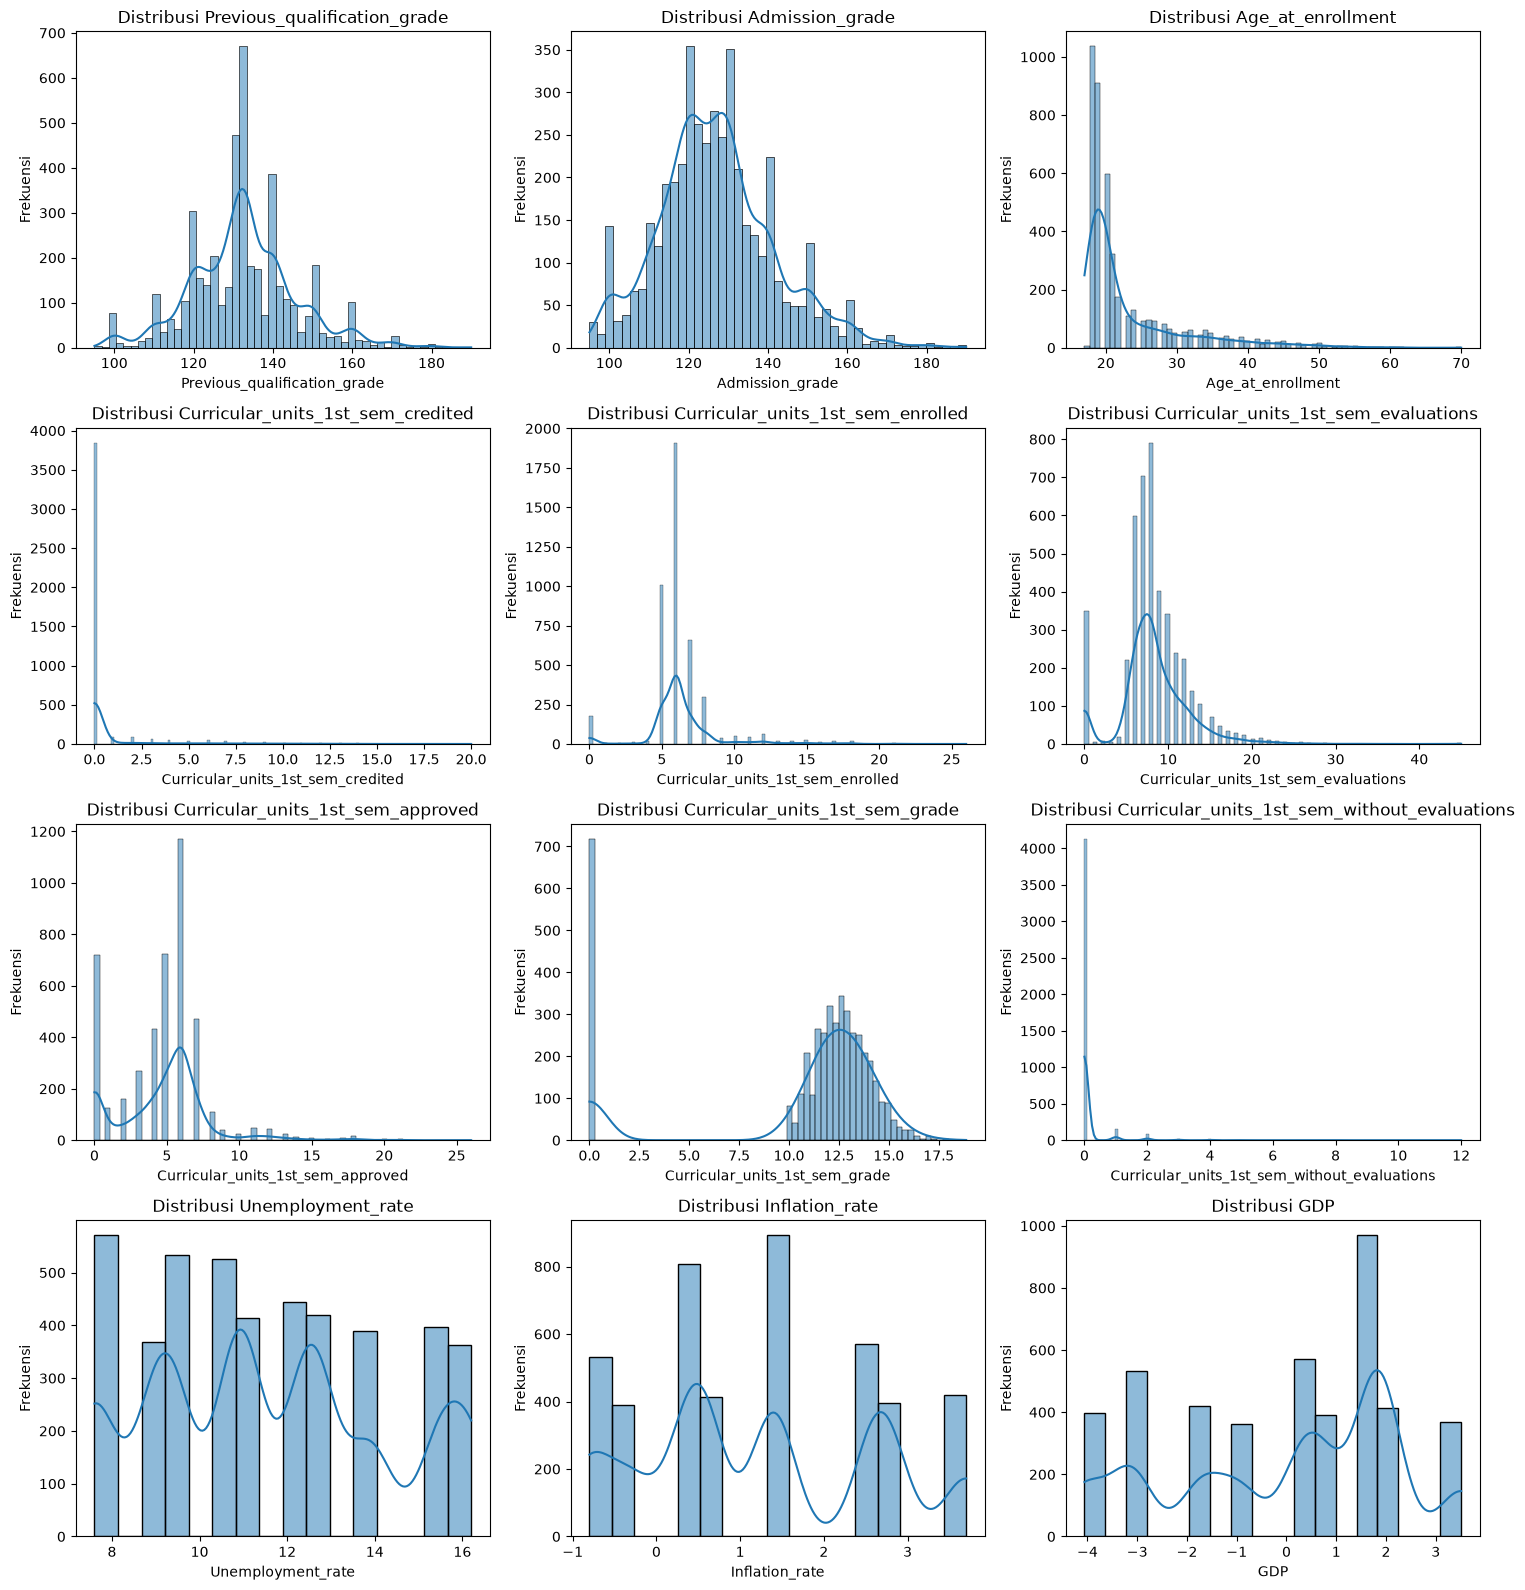

In [22]:
numerical_features = [
    'Previous_qualification_grade',
    'Admission_grade',
    'Age_at_enrollment',
    'Curricular_units_1st_sem_credited',
    'Curricular_units_1st_sem_enrolled',
    'Curricular_units_1st_sem_evaluations',
    'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade',
    'Curricular_units_1st_sem_without_evaluations',
    'Unemployment_rate',
    'Inflation_rate',
    'GDP'
]

fig, axes = plt.subplots(4, 3, figsize=(15, 16))

for ax, col in zip(axes.flatten(), numerical_features):
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(f'Distribusi {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

#### Interpretasi

Berdasarkan histogram distribusi variabel numerik, terdapat beberapa pola yang terlihat pada karakteristik akademik, demografis, dan kondisi ekonomi mahasiswa.

Pada `Previous_qualification_grade` dan `Admission_grade`, sebagian besar nilai mahasiswa terkonsentrasi pada rentang sekitar **110 hingga 150**. Kedua variabel menunjukkan penyebaran nilai yang cukup luas, dengan beberapa nilai yang berada di bagian bawah maupun atas rentang tersebut.

Variabel `Age_at_enrollment` menunjukkan distribusi yang cenderung **miring ke kanan**. Sebagian besar mahasiswa mulai berkuliah pada usia sekitar akhir masa remaja hingga awal usia 20-an, sedangkan sebagian mahasiswa lainnya memiliki usia yang lebih tinggi hingga sekitar 70 tahun.

Pada variabel `Curricular_units_1st_sem_credited`, sebagian besar mahasiswa memiliki jumlah unit yang dikreditkan sebesar **0**. Nilai lainnya tersebar pada jumlah unit yang lebih tinggi tetapi dengan frekuensi yang jauh lebih rendah.

`Curricular_units_1st_sem_enrolled` menunjukkan bahwa jumlah unit yang diambil mahasiswa pada semester pertama paling banyak terkonsentrasi pada kisaran **5 hingga 7 unit**. Terdapat pula mahasiswa dengan jumlah unit yang lebih rendah maupun lebih tinggi.

Pada `Curricular_units_1st_sem_evaluations`, sebagian besar mahasiswa memiliki jumlah evaluasi pada kisaran sekitar **5 hingga 15 evaluasi**. Frekuensi semakin rendah pada jumlah evaluasi yang lebih tinggi.

Distribusi `Curricular_units_1st_sem_approved` menunjukkan konsentrasi nilai pada beberapa jumlah unit tertentu, terutama sekitar **5 hingga 7 unit**. Terdapat juga mahasiswa dengan jumlah unit yang disetujui lebih rendah, termasuk nilai 0.

Untuk `Curricular_units_1st_sem_grade`, sebagian besar nilai terkonsentrasi pada kisaran sekitar **10 hingga 15**. Terdapat pula cukup banyak data dengan nilai 0, yang menunjukkan bahwa sebagian mahasiswa memiliki kondisi akademik yang berbeda dari kelompok utama.

Variabel `Curricular_units_1st_sem_without_evaluations` sangat terkonsentrasi pada nilai **0**, sedangkan jumlah mahasiswa dengan unit tanpa evaluasi yang lebih tinggi jauh lebih sedikit.

Sementara itu, `Unemployment_rate`, `Inflation_rate`, dan `GDP` menunjukkan pola distribusi yang berbentuk beberapa kelompok nilai tertentu. Hal ini terjadi karena ketiga variabel tersebut memiliki jumlah nilai unik yang relatif terbatas dalam dataset, sehingga distribusinya tidak membentuk pola kontinu seperti variabel nilai akademik.

Secara keseluruhan, variabel numerik dalam dataset memiliki karakteristik distribusi yang berbeda-beda. Beberapa variabel akademik cenderung terkonsentrasi pada rentang nilai tertentu, sedangkan beberapa variabel lainnya memiliki distribusi yang miring atau sangat terkonsentrasi pada nilai tertentu. Informasi ini akan menjadi dasar untuk memahami hubungan antara karakteristik mahasiswa dan status akademiknya pada analisis berikutnya.

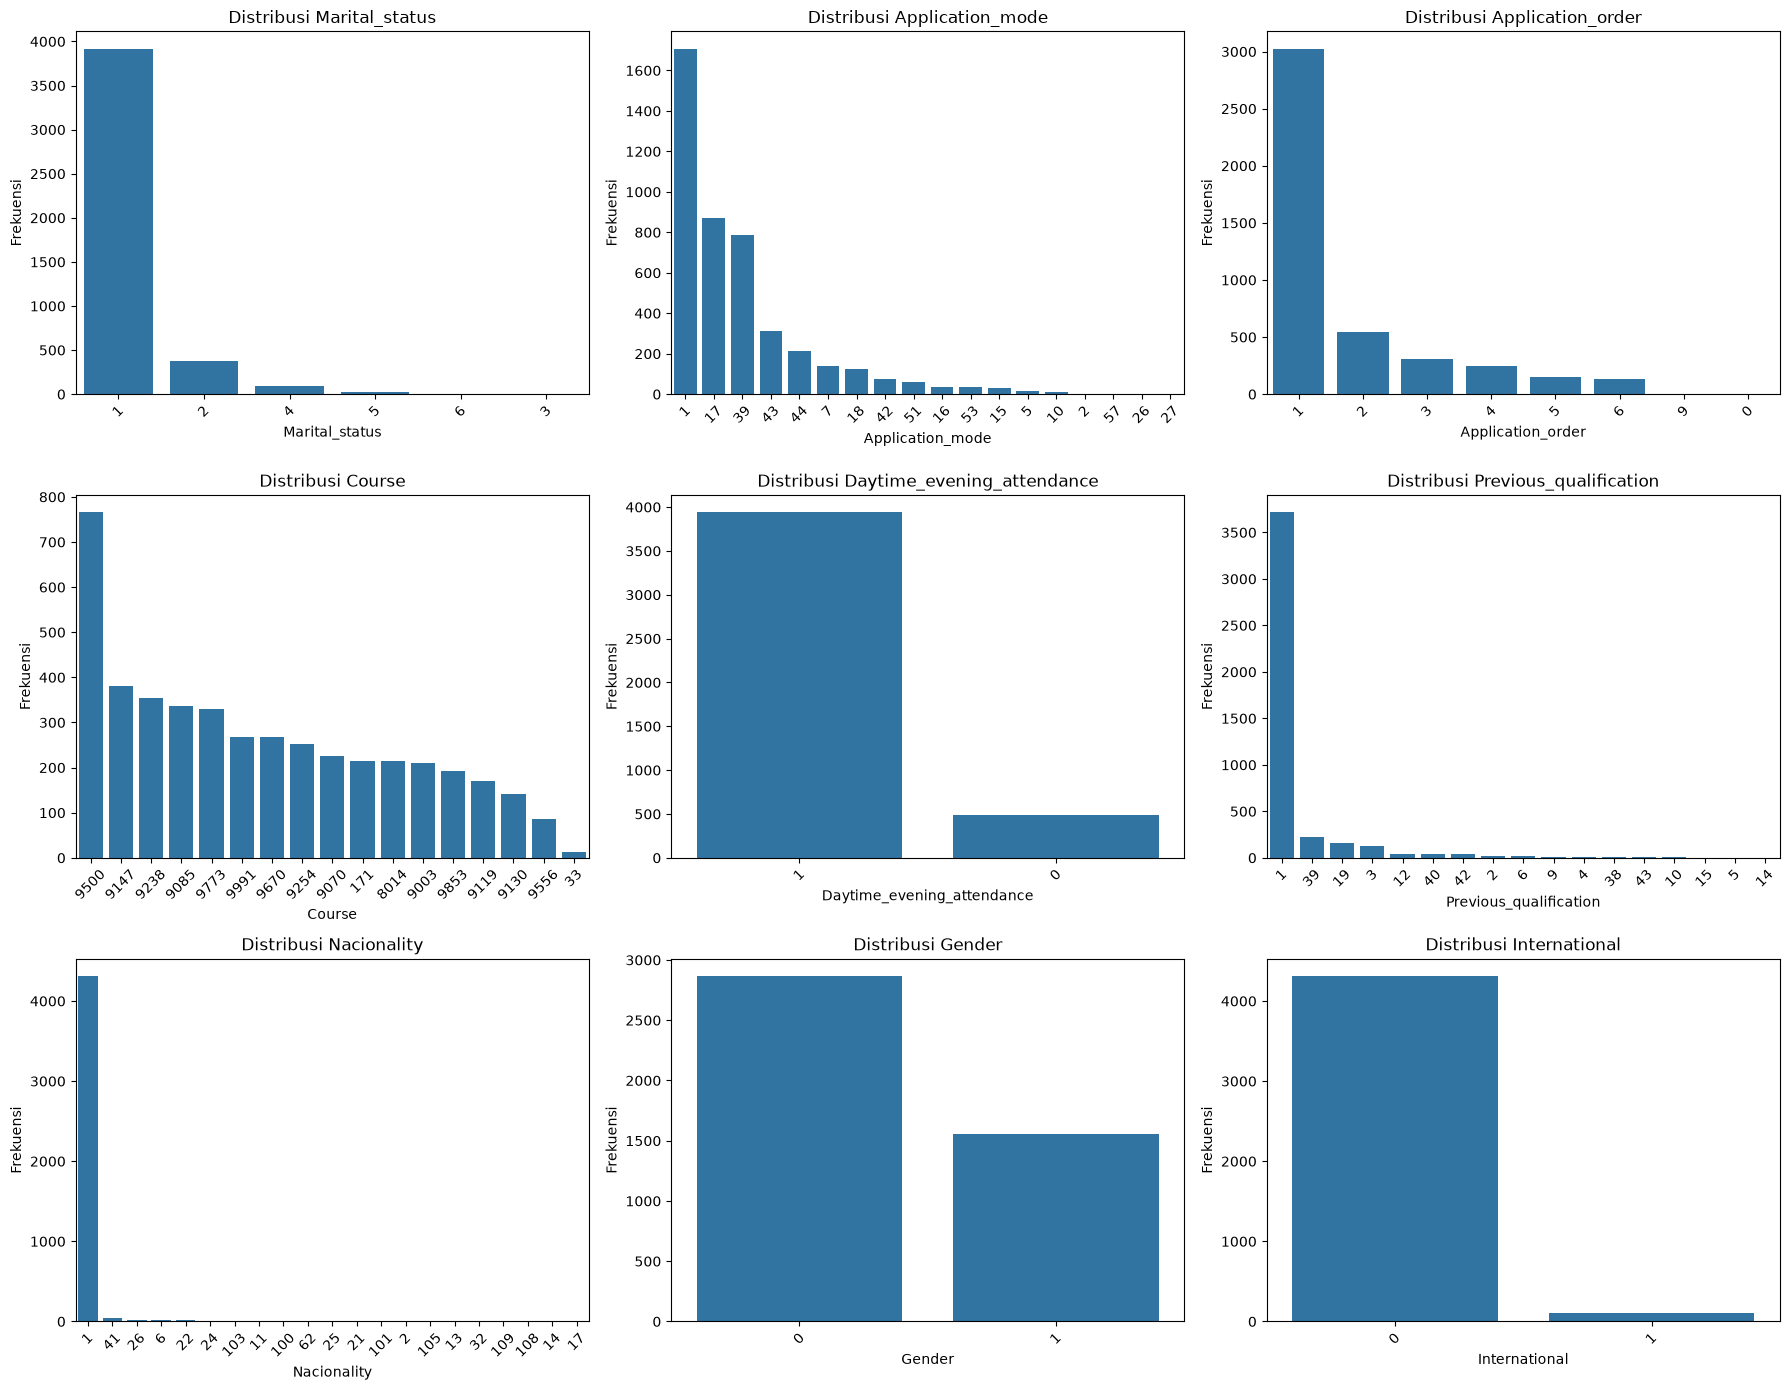

In [23]:
categorical_features_group1 = [
    'Marital_status',
    'Application_mode',
    'Application_order',
    'Course',
    'Daytime_evening_attendance',
    'Previous_qualification',
    'Nacionality',
    'Gender',
    'International'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))

for ax, col in zip(axes.flatten(), categorical_features_group1):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax)
    ax.set_title(f'Distribusi {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frekuensi')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### Interpretasi

Berdasarkan visualisasi distribusi variabel kategorikal kelompok pertama, terlihat bahwa sebagian besar variabel memiliki distribusi kategori yang tidak merata.

Pada `Marital_status`, kategori **1** memiliki jumlah mahasiswa yang jauh lebih banyak dibandingkan kategori lainnya. Sebagian besar mahasiswa berada pada kategori tersebut, sedangkan kategori lainnya memiliki jumlah yang jauh lebih kecil.

Pada `Application_mode`, distribusi mahasiswa terkonsentrasi pada beberapa kategori tertentu. Kategori **1** memiliki frekuensi paling tinggi, kemudian diikuti oleh kategori **17** dan **39**. Kategori lainnya memiliki jumlah mahasiswa yang lebih rendah.

Pada `Application_order`, kategori **1** merupakan kategori yang paling dominan. Frekuensi kategori kemudian menurun pada urutan pendaftaran yang lebih tinggi.

Variabel `Course` menunjukkan bahwa jumlah mahasiswa tersebar pada beberapa program studi, tetapi terdapat beberapa kode program studi yang memiliki jumlah mahasiswa lebih tinggi dibandingkan program studi lainnya. Kode **9500** memiliki frekuensi paling tinggi pada dataset.

Pada `Daytime_evening_attendance`, kategori **1** jauh lebih dominan dibandingkan kategori **0**. Hal ini menunjukkan bahwa sebagian besar mahasiswa dalam dataset termasuk dalam kategori waktu perkuliahan yang direpresentasikan oleh kode 1.

Distribusi `Previous_qualification` juga menunjukkan ketidakseimbangan antar kategori. Kategori **1** memiliki jumlah mahasiswa yang jauh lebih besar dibandingkan kategori lainnya, sedangkan beberapa kategori hanya memiliki jumlah mahasiswa yang relatif sedikit.

Pada `Nacionality`, kategori **1** sangat dominan dibandingkan kategori kewarganegaraan lainnya. Sebagian besar data mahasiswa berada pada kategori tersebut, sementara kategori lainnya memiliki frekuensi yang jauh lebih kecil.

Pada `Gender`, kategori **0** memiliki jumlah mahasiswa lebih banyak dibandingkan kategori **1**. Berdasarkan distribusi data, terdapat **2.868 mahasiswa** pada kategori 0 dan **1.556 mahasiswa** pada kategori 1.

Variabel `International` menunjukkan ketimpangan yang sangat besar antara kedua kategori. Kategori **0** mendominasi dataset, sedangkan kategori **1** hanya memiliki sebagian kecil data mahasiswa. Sebelumnya diketahui bahwa terdapat **4.314 mahasiswa** pada kategori 0 dan **110 mahasiswa** pada kategori 1.

Secara keseluruhan, beberapa variabel kategorikal memiliki distribusi kategori yang cukup tidak merata. Kondisi ini perlu diperhatikan pada tahap analisis hubungan dengan `Status`, karena kategori yang jumlahnya sangat sedikit dapat memiliki jumlah observasi yang terbatas ketika dibandingkan berdasarkan status mahasiswa.

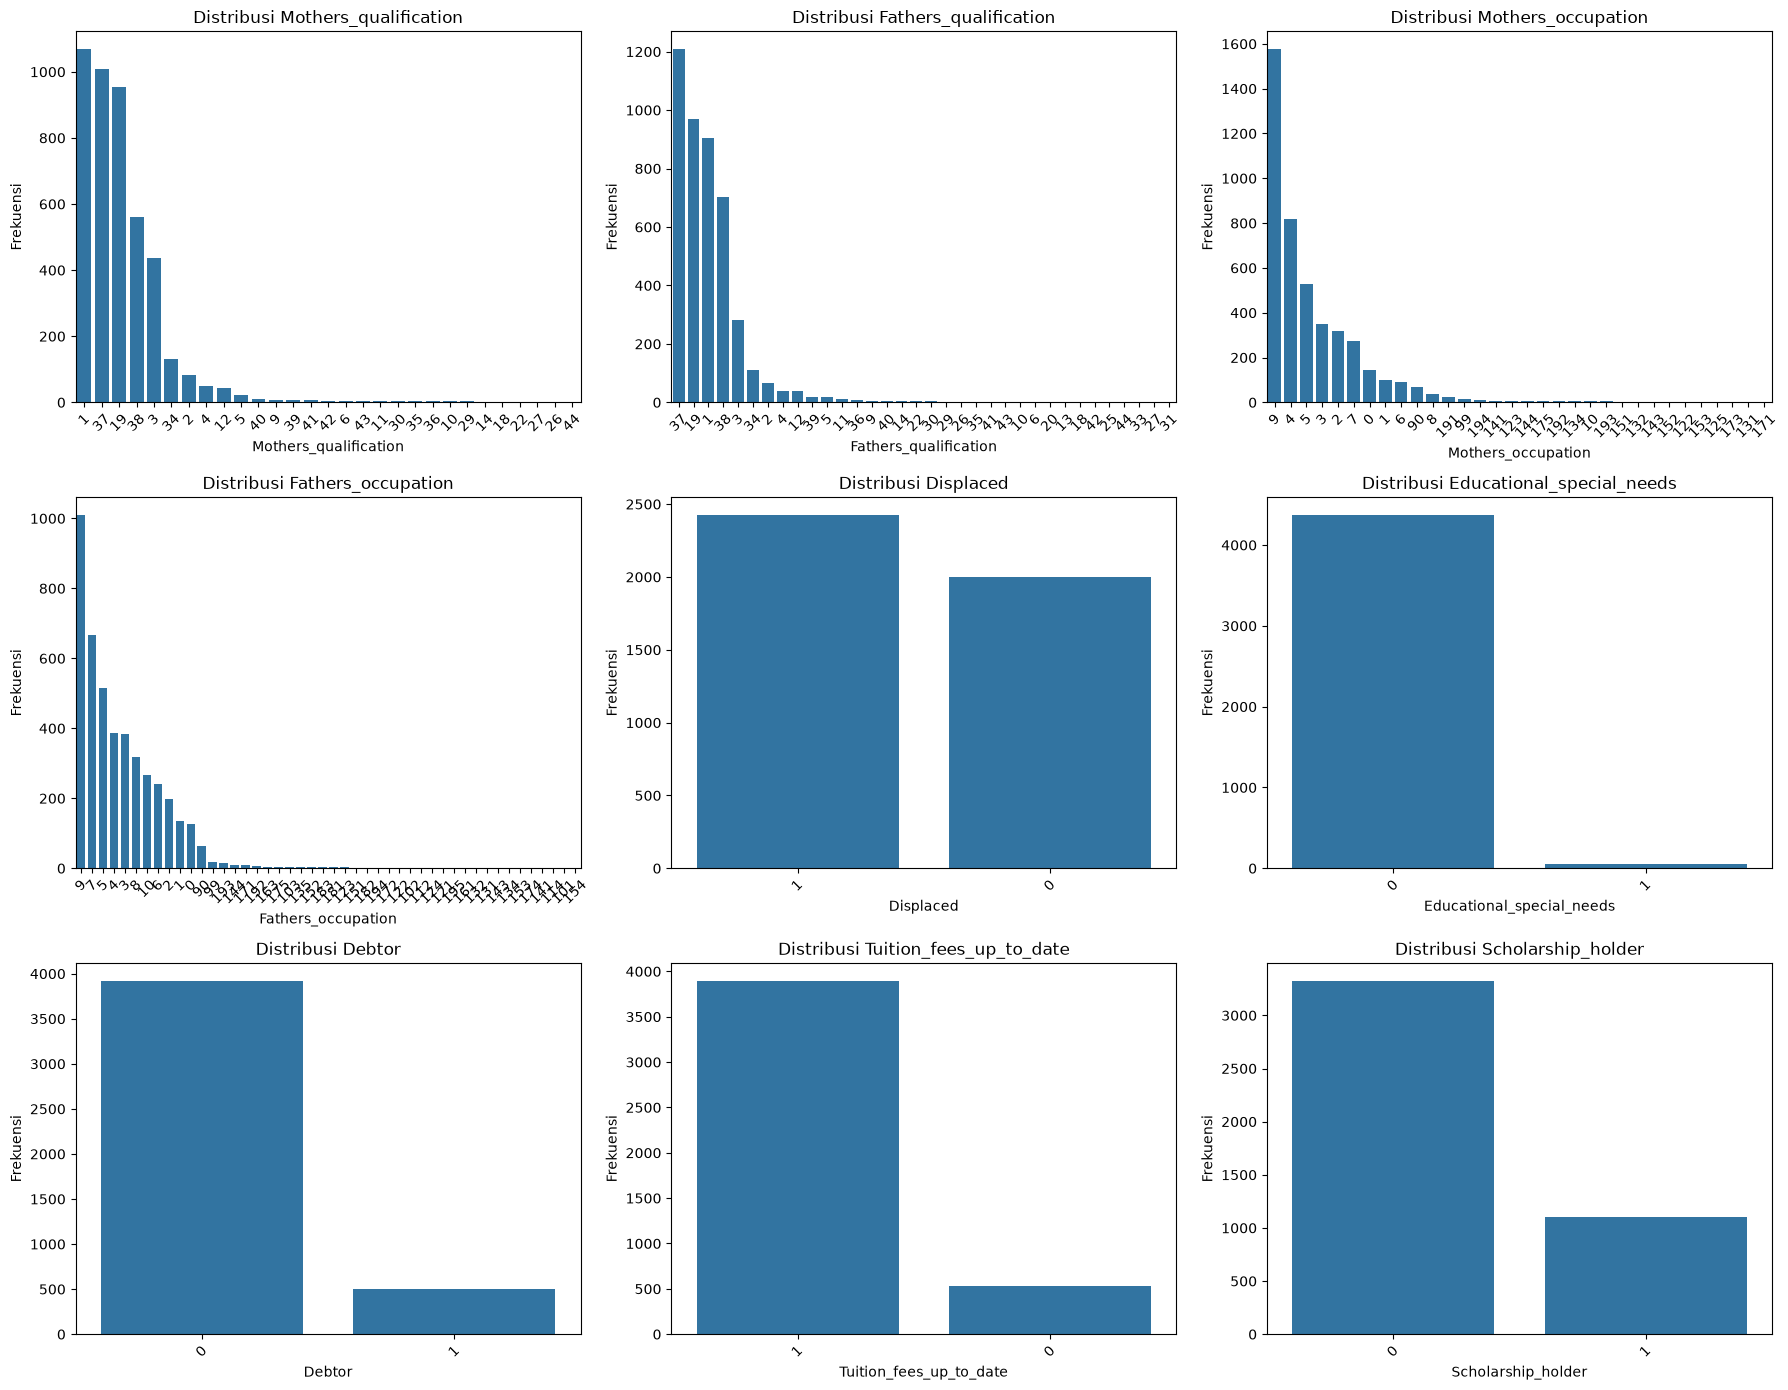

In [24]:
categorical_features_group2 = [
    'Mothers_qualification',
    'Fathers_qualification',
    'Mothers_occupation',
    'Fathers_occupation',
    'Displaced',
    'Educational_special_needs',
    'Debtor',
    'Tuition_fees_up_to_date',
    'Scholarship_holder'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))

for ax, col in zip(axes.flatten(), categorical_features_group2):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax)
    ax.set_title(f'Distribusi {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frekuensi')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### Interpretasi

Berdasarkan visualisasi distribusi variabel kategorikal kelompok kedua, terlihat bahwa karakteristik pendidikan dan pekerjaan orang tua serta kondisi mahasiswa memiliki distribusi kategori yang berbeda-beda.

Pada `Mothers_qualification`, terdapat beberapa kategori yang memiliki frekuensi jauh lebih tinggi dibandingkan kategori lainnya. Kategori **1**, **37**, dan **19** termasuk kategori yang paling banyak muncul, sedangkan sejumlah kategori lainnya memiliki frekuensi yang relatif rendah.

Pada `Fathers_qualification`, distribusi juga terkonsentrasi pada beberapa kategori utama. Kategori **1**, **37**, **19**, dan **38** memiliki frekuensi yang lebih tinggi dibandingkan kategori lainnya. Beberapa kategori lainnya hanya memiliki jumlah observasi yang sedikit.

Variabel `Mothers_occupation` menunjukkan distribusi yang cukup terkonsentrasi. Kategori **9** memiliki frekuensi paling tinggi, kemudian diikuti oleh kategori **4**, **5**, dan **3**. Sementara itu, banyak kategori pekerjaan lainnya memiliki jumlah mahasiswa yang jauh lebih rendah.

Pada `Fathers_occupation`, pola distribusinya juga menunjukkan adanya beberapa kategori pekerjaan yang dominan, sedangkan kategori lainnya memiliki frekuensi yang lebih kecil.

Variabel `Displaced` memiliki dua kategori. Distribusi mahasiswa pada kedua kategori tersebut relatif lebih seimbang dibandingkan beberapa variabel kategorikal lainnya, dengan kategori **1** berjumlah **2.426 mahasiswa** dan kategori **0** berjumlah **1.998 mahasiswa**.

Pada `Educational_special_needs`, kategori **0** sangat dominan dengan **4.373 mahasiswa**, sedangkan kategori **1** hanya berjumlah **51 mahasiswa**. Hal ini menunjukkan bahwa kategori tersebut memiliki distribusi yang sangat tidak seimbang.

Variabel `Debtor` menunjukkan bahwa sebagian besar mahasiswa berada pada kategori **0**, yaitu **3.921 mahasiswa**, sedangkan kategori **1** berjumlah **503 mahasiswa**.

Pada `Tuition_fees_up_to_date`, kategori **1** memiliki jumlah mahasiswa yang lebih besar, yaitu **3.896 mahasiswa**, sedangkan kategori **0** berjumlah **528 mahasiswa**.

Pada `Scholarship_holder`, terdapat **3.325 mahasiswa** pada kategori **0** dan **1.099 mahasiswa** pada kategori **1**. Dengan demikian, mahasiswa yang tidak termasuk kategori penerima beasiswa lebih banyak dibandingkan mahasiswa yang termasuk kategori penerima beasiswa.

Secara keseluruhan, sebagian besar variabel kategorikal pada kelompok kedua memiliki distribusi yang tidak merata. Beberapa kategori sangat dominan, sementara kategori lainnya memiliki jumlah observasi yang relatif sedikit. Kondisi ini perlu diperhatikan pada analisis hubungan antara fitur dengan `Status`, terutama ketika membandingkan kategori-kategori yang memiliki jumlah data kecil.

### Analisis Bivariate

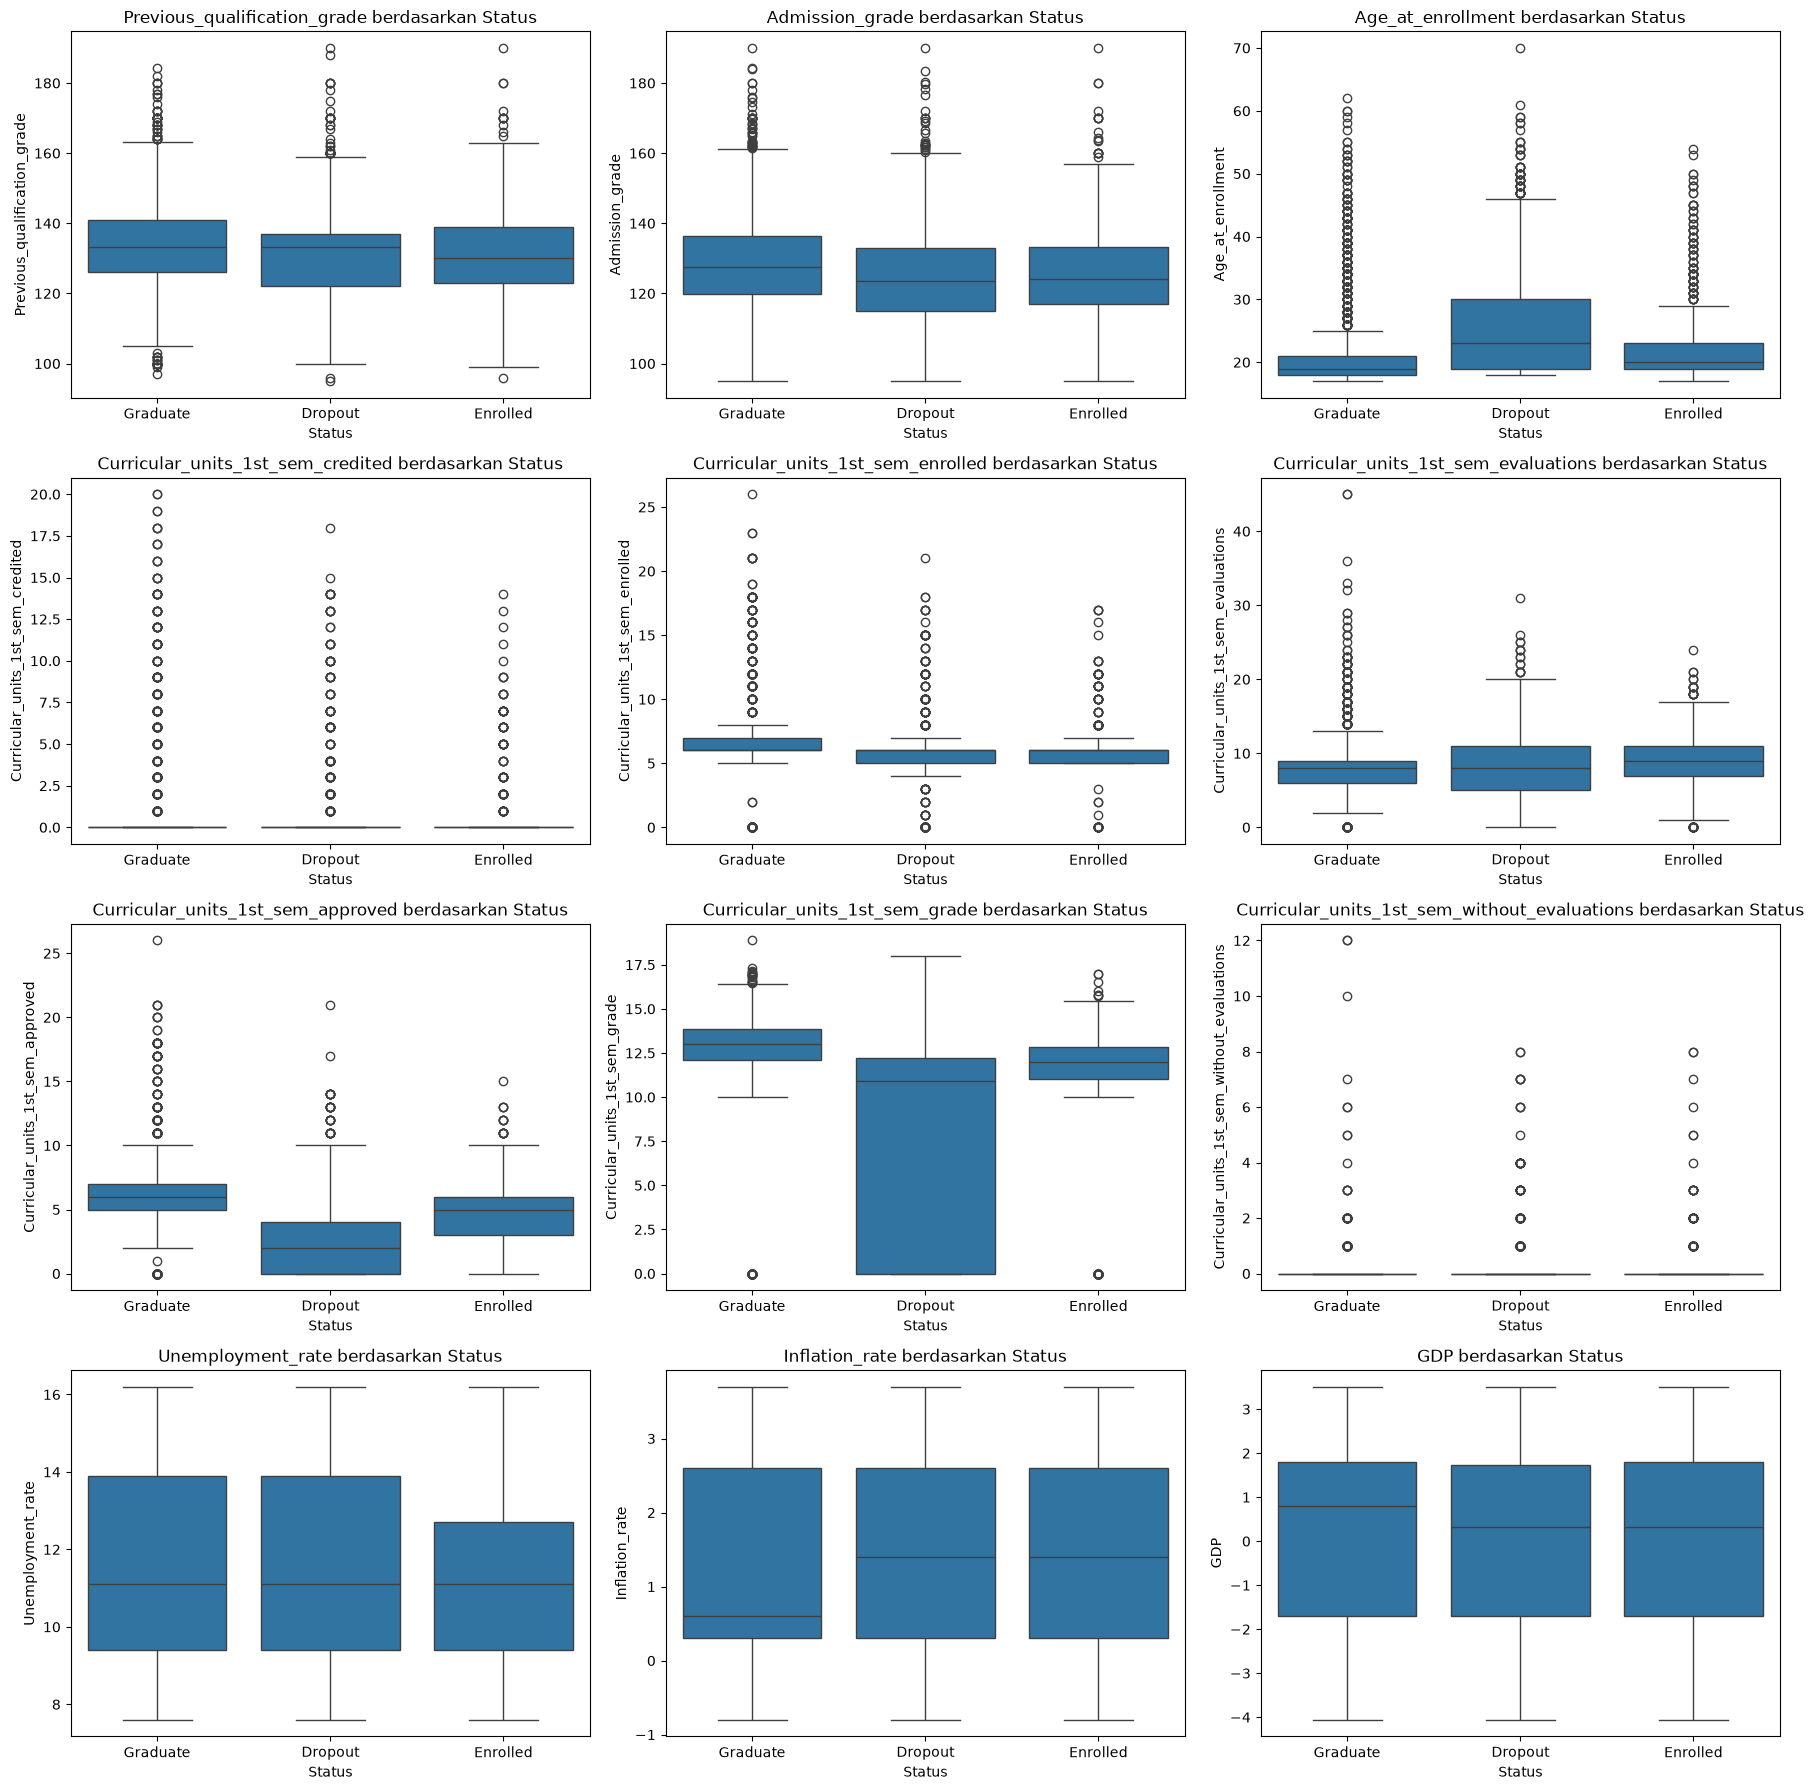

In [26]:
fig, axes = plt.subplots(4, 3, figsize=(18, 18))

for ax, col in zip(axes.flatten(), numerical_features):
    sns.boxplot(
        data=df,
        x='Status',
        y=col,
        order=['Graduate', 'Dropout', 'Enrolled'],
        ax=ax
    )
    ax.set_title(f'{col} berdasarkan Status')
    ax.set_xlabel('Status')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

#### Interpretasi

Berdasarkan hasil analisis bivariat menggunakan boxplot, terlihat adanya perbedaan distribusi beberapa variabel numerik pada masing-masing status mahasiswa.

Pada `Previous_qualification_grade`, median antar kelompok `Graduate`, `Dropout`, dan `Enrolled` terlihat relatif berdekatan. Meskipun terdapat perbedaan kecil pada posisi median dan sebaran data, variabel ini tidak menunjukkan perbedaan yang sangat besar antar ketiga status.

Pada `Admission_grade`, kelompok `Graduate` memiliki median yang sedikit lebih tinggi dibandingkan `Dropout` dan `Enrolled`. Namun, ketiga kelompok masih memiliki rentang nilai yang cukup berdekatan dan terdapat banyak nilai di luar rentang utama.

`Age_at_enrollment` menunjukkan perbedaan yang lebih terlihat. Kelompok `Dropout` memiliki median usia pendaftaran yang lebih tinggi dibandingkan `Graduate` dan `Enrolled`. Kelompok `Graduate` dan `Enrolled` memiliki median yang relatif lebih rendah, meskipun keduanya juga memiliki sejumlah mahasiswa dengan usia pendaftaran yang lebih tinggi.

Pada `Curricular_units_1st_sem_credited`, sebagian besar mahasiswa pada ketiga status memiliki nilai yang berada di sekitar **0**. Terdapat sejumlah observasi dengan jumlah unit yang lebih tinggi, tetapi frekuensinya relatif rendah.

`Curricular_units_1st_sem_enrolled` menunjukkan adanya perbedaan antar status. Kelompok `Graduate` cenderung memiliki median jumlah unit yang diambil sedikit lebih tinggi dibandingkan `Dropout` dan `Enrolled`.

Pada `Curricular_units_1st_sem_evaluations`, kelompok `Enrolled` memiliki median yang terlihat lebih tinggi dibandingkan `Graduate`, sedangkan `Dropout` berada di antara keduanya. Ketiga kelompok tetap memiliki penyebaran yang cukup luas dan terdapat beberapa nilai ekstrem.

Perbedaan yang cukup jelas terlihat pada `Curricular_units_1st_sem_approved`. Kelompok `Graduate` memiliki median jumlah unit yang disetujui lebih tinggi dibandingkan `Dropout`, sedangkan `Enrolled` berada di antara kedua kelompok tersebut. Kelompok `Dropout` juga memiliki penyebaran nilai yang lebih luas.

Pada `Curricular_units_1st_sem_grade`, terdapat perbedaan distribusi yang cukup menonjol. Kelompok `Graduate` memiliki median nilai yang lebih tinggi, sedangkan `Dropout` memiliki median yang lebih rendah dan penyebaran yang jauh lebih lebar. Kelompok `Enrolled` memiliki median yang berada di antara `Graduate` dan `Dropout`.

Variabel `Curricular_units_1st_sem_without_evaluations` memiliki median **0** pada ketiga status. Sebagian besar mahasiswa tidak memiliki unit yang belum dievaluasi, meskipun terdapat beberapa observasi dengan nilai yang lebih tinggi.

Untuk `Unemployment_rate`, distribusi ketiga status terlihat relatif serupa. Median masing-masing kelompok berada pada kisaran yang berdekatan sehingga tidak terlihat perbedaan yang besar berdasarkan status mahasiswa.

Pada `Inflation_rate`, terdapat sedikit perbedaan posisi median antar kelompok, tetapi ketiga kelompok masih memiliki rentang distribusi yang cukup mirip.

`GDP` juga menunjukkan distribusi yang relatif serupa pada ketiga status. Meskipun terdapat sedikit perbedaan pada median, rentang nilai antar kelompok secara umum masih saling tumpang tindih.

Secara keseluruhan, beberapa fitur akademik semester pertama, khususnya `Curricular_units_1st_sem_approved` dan `Curricular_units_1st_sem_grade`, menunjukkan perbedaan distribusi yang lebih terlihat antar status mahasiswa dibandingkan variabel ekonomi. `Age_at_enrollment` juga menunjukkan perbedaan distribusi antar kelompok. Temuan ini memberikan indikasi awal bahwa karakteristik akademik pada semester pertama dan beberapa karakteristik mahasiswa dapat memiliki hubungan dengan `Status`, yang selanjutnya perlu dianalisis menggunakan fitur kategorikal dan analisis multivariat.

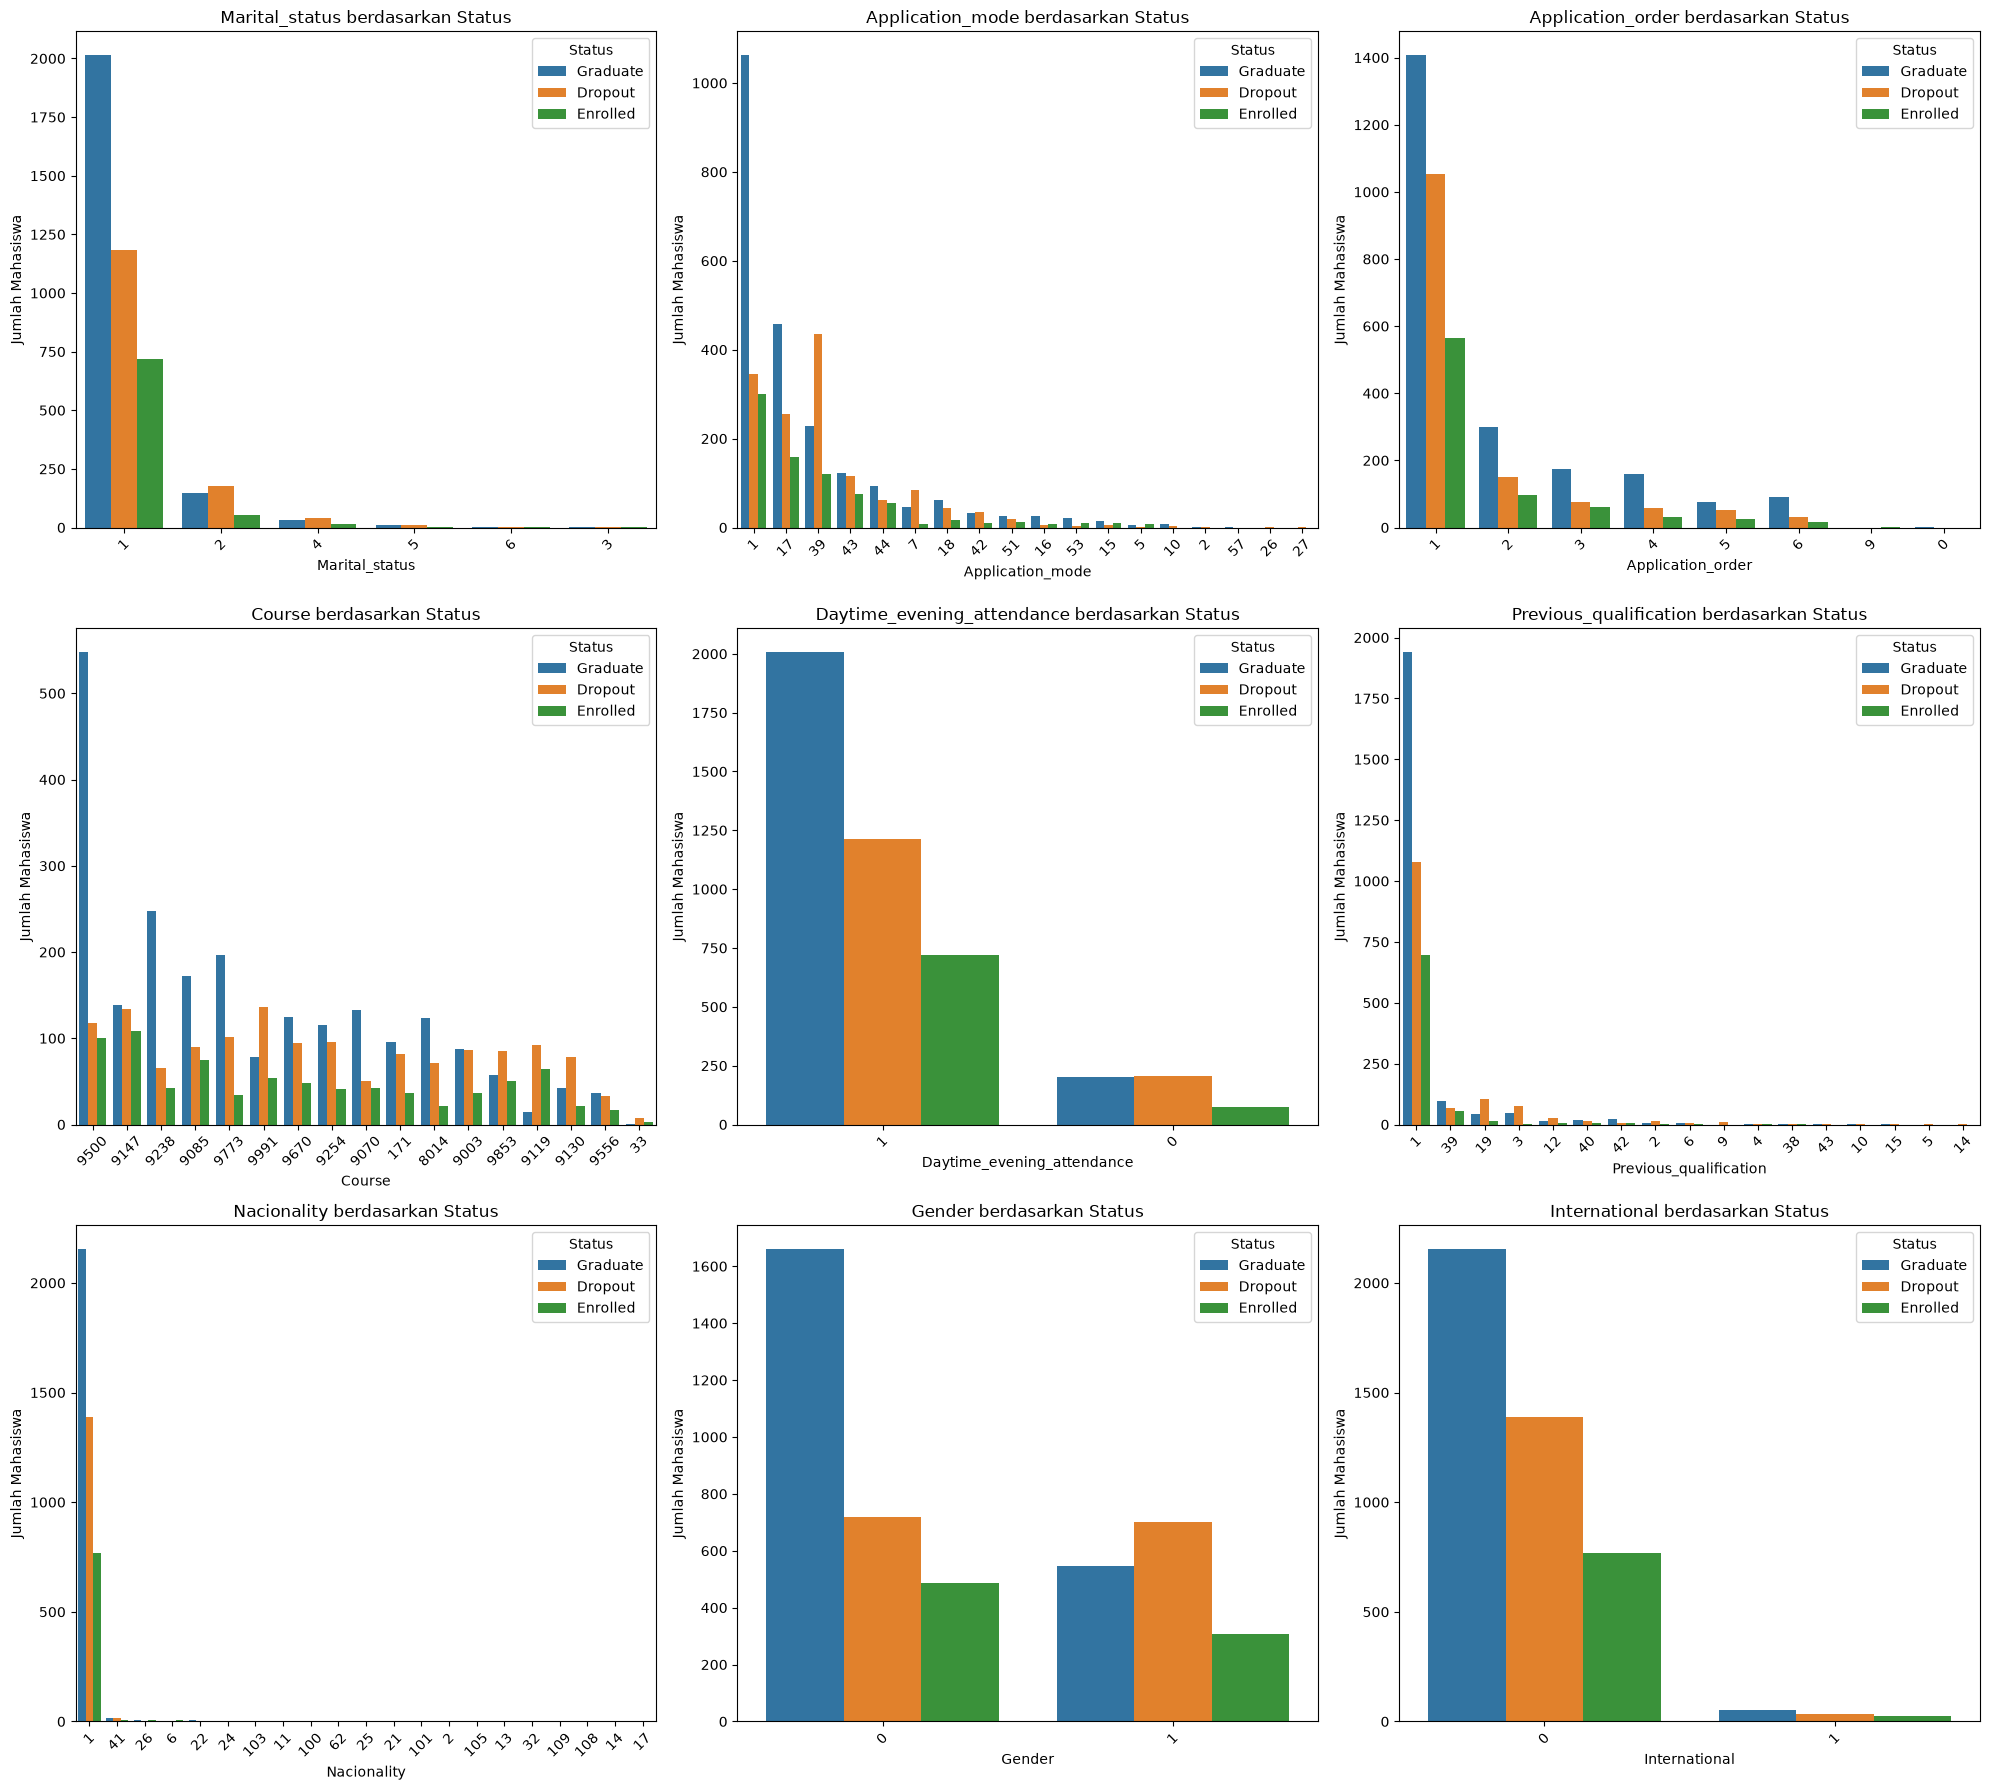

In [27]:
categorical_features_group1 = [
    'Marital_status',
    'Application_mode',
    'Application_order',
    'Course',
    'Daytime_evening_attendance',
    'Previous_qualification',
    'Nacionality',
    'Gender',
    'International'
]

fig, axes = plt.subplots(3, 3, figsize=(20, 18))

for ax, col in zip(axes.flatten(), categorical_features_group1):
    sns.countplot(
        data=df,
        x=col,
        hue='Status',
        order=df[col].value_counts().index,
        hue_order=['Graduate', 'Dropout', 'Enrolled'],
        ax=ax
    )
    ax.set_title(f'{col} berdasarkan Status')
    ax.set_xlabel(col)
    ax.set_ylabel('Jumlah Mahasiswa')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### Interpretasi

Berdasarkan visualisasi hubungan antara variabel kategorikal dengan `Status`, terlihat adanya perbedaan distribusi status mahasiswa pada beberapa kategori.

Pada `Marital_status`, kategori **1** merupakan kategori yang paling dominan untuk ketiga status mahasiswa. Pada kategori tersebut, jumlah `Graduate` terlihat paling tinggi, diikuti `Dropout` dan `Enrolled`. Kategori lainnya memiliki jumlah data yang jauh lebih sedikit sehingga pola antar status terlihat lebih kecil.

Pada `Application_mode`, distribusi `Status` berbeda pada beberapa kategori. Kategori **1** didominasi oleh mahasiswa `Graduate`, sedangkan kategori **39** menunjukkan jumlah `Dropout` yang relatif tinggi dibandingkan `Graduate` dan `Enrolled`. Beberapa kategori lainnya juga menunjukkan perbedaan jumlah antar status, meskipun jumlah observasinya lebih kecil.

Pada `Application_order`, kategori **1** memiliki jumlah mahasiswa paling banyak untuk seluruh status. Pada kategori ini, `Graduate` memiliki jumlah tertinggi, kemudian `Dropout` dan `Enrolled`. Pada kategori dengan urutan pendaftaran yang lebih tinggi, jumlah mahasiswa secara umum lebih sedikit.

Pada `Course`, terlihat bahwa distribusi status berbeda pada beberapa program studi. Beberapa kode program studi memiliki jumlah `Graduate` yang lebih tinggi, sedangkan pada beberapa program studi lainnya jumlah `Dropout` terlihat relatif besar. Perbedaan tersebut menunjukkan bahwa komposisi status mahasiswa tidak sepenuhnya sama pada setiap program studi.

Pada `Daytime_evening_attendance`, kategori **1** memiliki jumlah mahasiswa yang jauh lebih besar dibandingkan kategori **0**. Pada kedua kategori tersebut terdapat ketiga status mahasiswa, dengan `Graduate` memiliki jumlah yang tinggi pada kategori 1. Perbandingan ini juga menunjukkan bahwa jumlah data pada kategori 0 jauh lebih kecil.

Pada `Previous_qualification`, kategori **1** merupakan kategori yang paling dominan dan memiliki jumlah mahasiswa `Graduate`, `Dropout`, dan `Enrolled` yang jauh lebih tinggi dibandingkan kategori lainnya. Kategori-kategori lain memiliki jumlah observasi yang lebih sedikit sehingga distribusi statusnya juga lebih kecil.

Pada `Nacionality`, kategori **1** sangat dominan dibandingkan kategori lainnya. Ketiga status mahasiswa sebagian besar berada pada kategori tersebut. Kategori kewarganegaraan lainnya memiliki jumlah observasi yang sangat kecil sehingga perbandingan antar status pada kategori tersebut perlu dilakukan dengan hati-hati.

Pada `Gender`, terdapat perbedaan komposisi status antar kedua kategori. Pada kategori **0**, jumlah `Graduate` terlihat lebih tinggi dibandingkan `Dropout` dan `Enrolled`. Sementara itu, pada kategori **1**, jumlah `Dropout` terlihat lebih tinggi dibandingkan `Graduate`, sedangkan `Enrolled` tetap menjadi kategori dengan jumlah yang lebih rendah.

Pada `International`, sebagian besar mahasiswa berada pada kategori **0** dan ketiga status mahasiswa juga paling banyak terdapat pada kategori tersebut. Kategori **1** memiliki jumlah mahasiswa yang jauh lebih sedikit, sehingga jumlah setiap status pada kategori tersebut juga relatif kecil.

Secara keseluruhan, visualisasi menunjukkan bahwa distribusi `Status` tidak selalu sama pada setiap kategori fitur. Beberapa variabel seperti `Application_mode`, `Course`, dan `Gender` memperlihatkan perbedaan komposisi status yang cukup terlihat. Namun, karena beberapa kategori memiliki jumlah observasi yang sangat kecil, perbedaan jumlah tersebut belum dapat digunakan untuk menyimpulkan hubungan secara statistik. Analisis lebih lanjut akan dilakukan pada tahap berikutnya menggunakan beberapa variabel secara bersamaan.

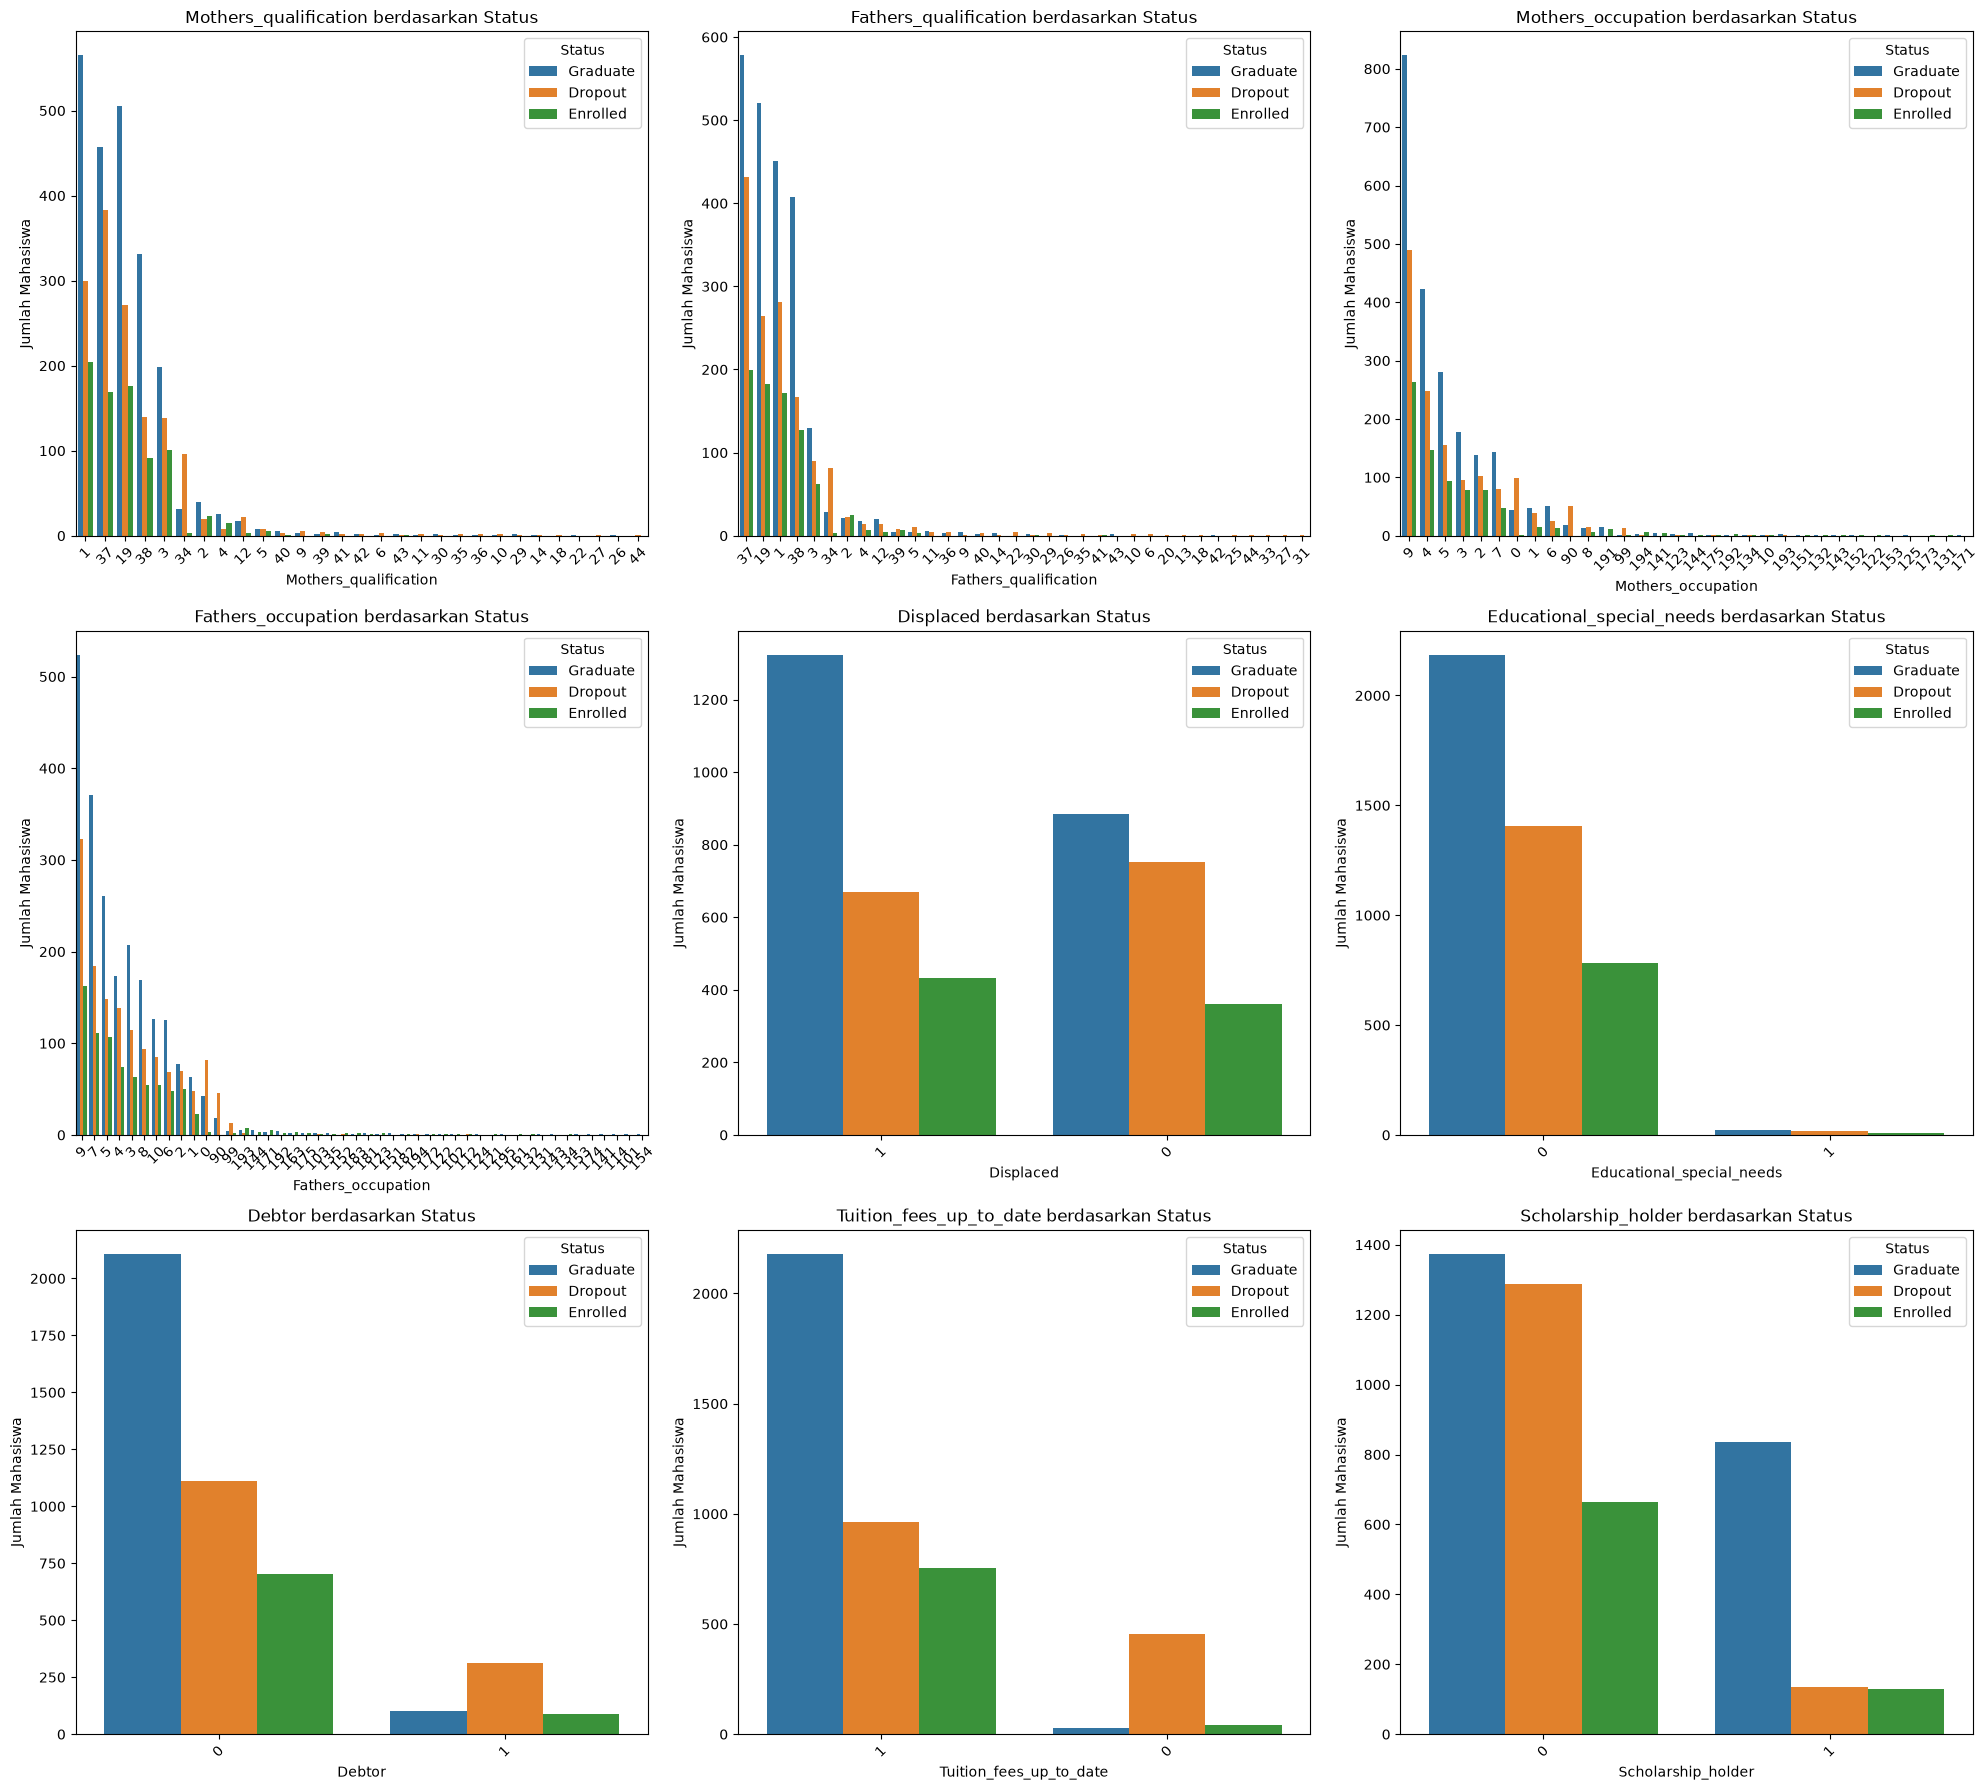

In [28]:
categorical_features_group2 = [
    'Mothers_qualification',
    'Fathers_qualification',
    'Mothers_occupation',
    'Fathers_occupation',
    'Displaced',
    'Educational_special_needs',
    'Debtor',
    'Tuition_fees_up_to_date',
    'Scholarship_holder'
]

fig, axes = plt.subplots(3, 3, figsize=(20, 18))

for ax, col in zip(axes.flatten(), categorical_features_group2):
    sns.countplot(
        data=df,
        x=col,
        hue='Status',
        order=df[col].value_counts().index,
        hue_order=['Graduate', 'Dropout', 'Enrolled'],
        ax=ax
    )
    ax.set_title(f'{col} berdasarkan Status')
    ax.set_xlabel(col)
    ax.set_ylabel('Jumlah Mahasiswa')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### Interpretasi

Berdasarkan visualisasi hubungan variabel kategorikal kelompok kedua dengan `Status`, terlihat adanya perbedaan jumlah mahasiswa pada masing-masing kategori dan status.

Pada `Mothers_qualification`, kategori dengan jumlah mahasiswa terbesar juga menunjukkan jumlah `Graduate` yang lebih tinggi dibandingkan `Dropout` dan `Enrolled`. Pola yang serupa terlihat pada beberapa kategori utama lainnya, meskipun terdapat perbedaan jumlah antar status.

Pada `Fathers_qualification`, beberapa kategori utama memiliki jumlah `Graduate` yang lebih tinggi dibandingkan `Dropout` dan `Enrolled`. Kategori dengan jumlah observasi yang lebih kecil menunjukkan jumlah mahasiswa yang lebih rendah pada ketiga status.

Pada `Mothers_occupation`, terdapat beberapa kategori pekerjaan yang memiliki jumlah mahasiswa jauh lebih tinggi dibandingkan kategori lainnya. Pada kategori-kategori utama tersebut, `Graduate` secara umum memiliki jumlah yang lebih tinggi dibandingkan `Dropout` dan `Enrolled`.

Pada `Fathers_occupation`, distribusi juga terkonsentrasi pada beberapa kategori pekerjaan utama. Ketiga status terdapat pada kategori-kategori tersebut, dengan jumlah `Graduate` yang umumnya lebih tinggi dibandingkan dua status lainnya.

Pada `Displaced`, kedua kategori memiliki ketiga status mahasiswa. Kategori **1** memiliki jumlah `Graduate` sekitar **1.300 mahasiswa**, sedangkan kategori **0** memiliki jumlah `Graduate` sekitar **880 mahasiswa**. Perbedaan juga terlihat pada `Dropout` dan `Enrolled`, meskipun pola jumlah ketiga status tetap perlu mempertimbangkan jumlah keseluruhan data pada masing-masing kategori.

Pada `Educational_special_needs`, kategori **0** sangat dominan dan memiliki jumlah mahasiswa yang jauh lebih besar dibandingkan kategori **1**. Pada kategori 0, jumlah `Graduate` merupakan yang terbesar, diikuti `Dropout` dan `Enrolled`. Karena kategori 1 memiliki jumlah observasi yang sangat sedikit, perbandingan status pada kategori tersebut perlu dilakukan dengan hati-hati.

Pada `Debtor`, kategori **0** memiliki jumlah mahasiswa yang jauh lebih besar dibandingkan kategori **1**. Pada kategori 0, `Graduate` merupakan status dengan jumlah tertinggi. Sementara itu, pada kategori 1 terlihat jumlah `Dropout` lebih tinggi dibandingkan `Graduate` dan `Enrolled`.

Pada `Tuition_fees_up_to_date`, kategori **1** sangat dominan. Pada kategori tersebut, `Graduate` memiliki jumlah paling tinggi, diikuti `Dropout` dan `Enrolled`. Pada kategori **0**, jumlah `Dropout` terlihat lebih tinggi dibandingkan `Graduate` dan `Enrolled`.

Pada `Scholarship_holder`, kategori **0** memiliki jumlah mahasiswa lebih besar dibandingkan kategori **1**. Pada kategori 0, jumlah `Graduate` dan `Dropout` terlihat relatif tinggi. Sementara itu, pada kategori 1, jumlah `Graduate` terlihat lebih tinggi dibandingkan `Dropout` dan `Enrolled`.

Secara keseluruhan, beberapa variabel kategorikal menunjukkan perbedaan komposisi `Status` yang cukup terlihat, terutama `Debtor`, `Tuition_fees_up_to_date`, `Scholarship_holder`, dan `Displaced`. Namun, visualisasi ini menunjukkan hubungan berdasarkan jumlah observasi dan belum membuktikan hubungan sebab-akibat maupun signifikansi statistik. Selain itu, kategori dengan jumlah observasi yang sangat kecil perlu ditafsirkan dengan hati-hati.

Hasil Bivariate Analysis ini akan menjadi dasar untuk melihat pola yang lebih kompleks pada tahap Multivariate Analysis.

### Analisis Multivariate

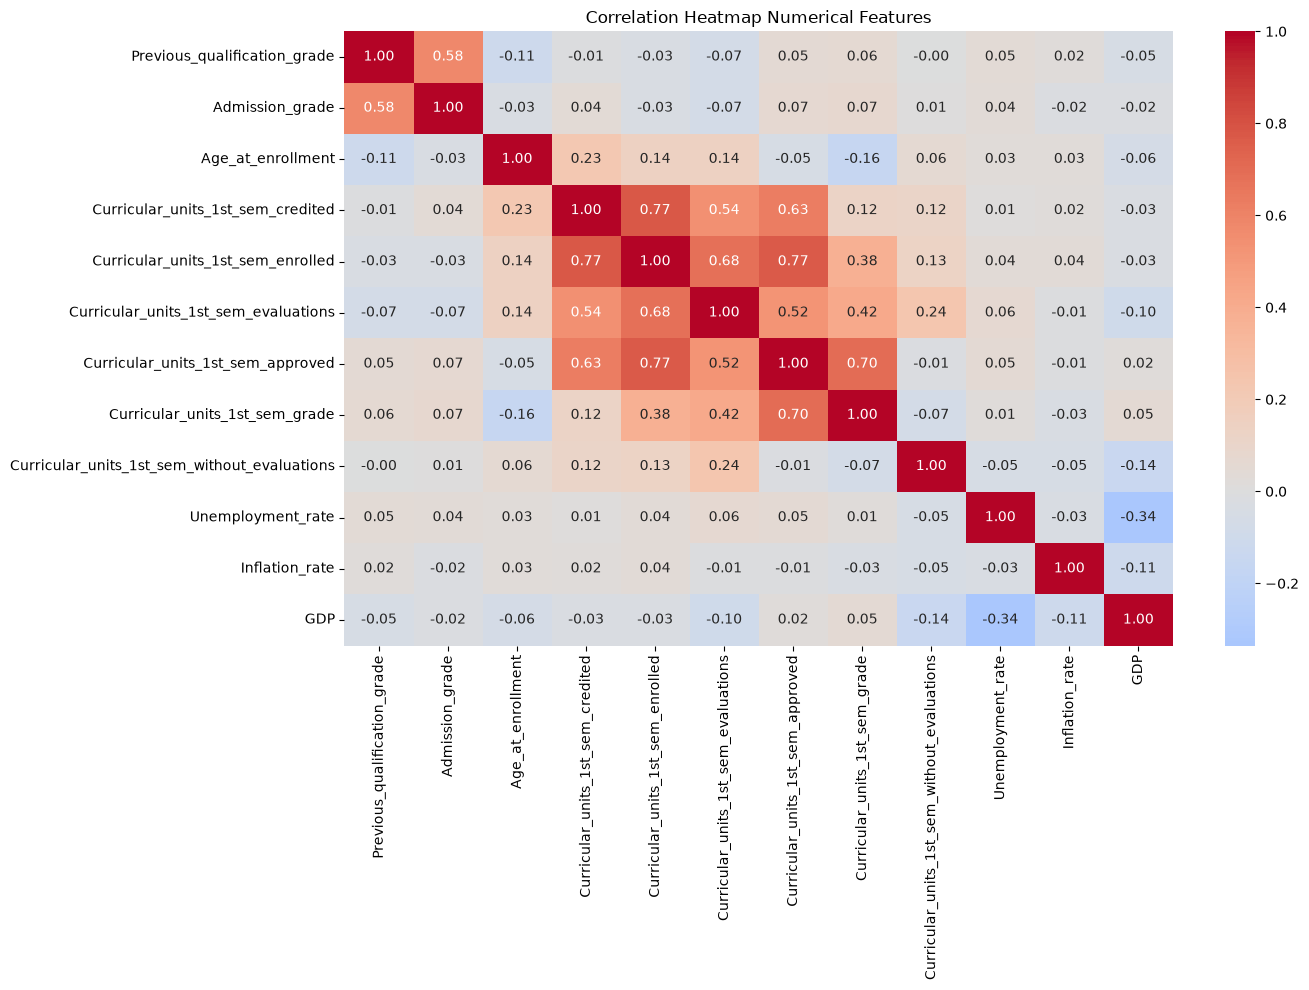

In [29]:
plt.figure(figsize=(14, 10))

correlation_matrix = df[numerical_features].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap Numerical Features')
plt.tight_layout()
plt.show()

#### Interpretasi

Berdasarkan correlation heatmap, terdapat beberapa hubungan yang terlihat cukup kuat antar variabel numerik.

`Previous_qualification_grade` memiliki korelasi positif sebesar **0,58** dengan `Admission_grade`. Hal ini menunjukkan adanya hubungan linear positif yang cukup kuat antara nilai kualifikasi sebelumnya dan nilai penerimaan. Mahasiswa dengan nilai kualifikasi sebelumnya yang lebih tinggi cenderung memiliki nilai penerimaan yang lebih tinggi pula.

Pada variabel akademik semester pertama, terlihat beberapa korelasi yang cukup kuat. `Curricular_units_1st_sem_credited` memiliki korelasi **0,77** dengan `Curricular_units_1st_sem_enrolled`, sedangkan korelasi dengan `Curricular_units_1st_sem_approved` sebesar **0,63**. Hal ini menunjukkan adanya hubungan positif antara jumlah unit yang dikreditkan, jumlah unit yang diambil, dan jumlah unit yang disetujui.

`Curricular_units_1st_sem_enrolled` memiliki korelasi **0,68** dengan `Curricular_units_1st_sem_evaluations` dan **0,77** dengan `Curricular_units_1st_sem_approved`. Artinya, mahasiswa yang mengambil lebih banyak unit pada semester pertama cenderung memiliki jumlah evaluasi dan unit yang disetujui lebih tinggi.

`Curricular_units_1st_sem_approved` juga memiliki korelasi **0,70** dengan `Curricular_units_1st_sem_grade`. Hubungan ini menunjukkan bahwa jumlah unit yang disetujui memiliki hubungan positif yang cukup kuat dengan nilai akademik semester pertama.

Sementara itu, `Curricular_units_1st_sem_evaluations` memiliki korelasi **0,42** dengan `Curricular_units_1st_sem_grade`, yang menunjukkan hubungan positif dengan kekuatan sedang. `Curricular_units_1st_sem_enrolled` juga memiliki korelasi **0,38** dengan `Curricular_units_1st_sem_grade`.

`Age_at_enrollment` memiliki beberapa hubungan yang relatif lemah dengan fitur akademik. Salah satu hubungan yang terlihat adalah korelasi negatif sebesar **-0,16** dengan `Curricular_units_1st_sem_grade`. Nilai tersebut menunjukkan hubungan linear negatif yang lemah.

Pada variabel ekonomi, `Unemployment_rate` dan `GDP` memiliki korelasi negatif sebesar **-0,34**. Sementara itu, hubungan antara `Inflation_rate` dengan sebagian besar variabel lainnya relatif lemah.

Secara keseluruhan, korelasi paling kuat dalam heatmap terdapat pada beberapa fitur yang menggambarkan aktivitas akademik semester pertama, khususnya antara jumlah unit yang diambil, dikreditkan, dievaluasi, disetujui, dan nilai semester pertama. Hal ini menunjukkan bahwa beberapa fitur akademik memiliki informasi yang saling berkaitan.

Korelasi yang tinggi antar beberapa fitur juga perlu diperhatikan pada tahap pemodelan karena dapat menunjukkan adanya informasi yang tumpang tindih antar fitur. Namun, korelasi tidak menunjukkan hubungan sebab-akibat dan tidak secara langsung menentukan fitur mana yang paling penting dalam memprediksi `Status`.

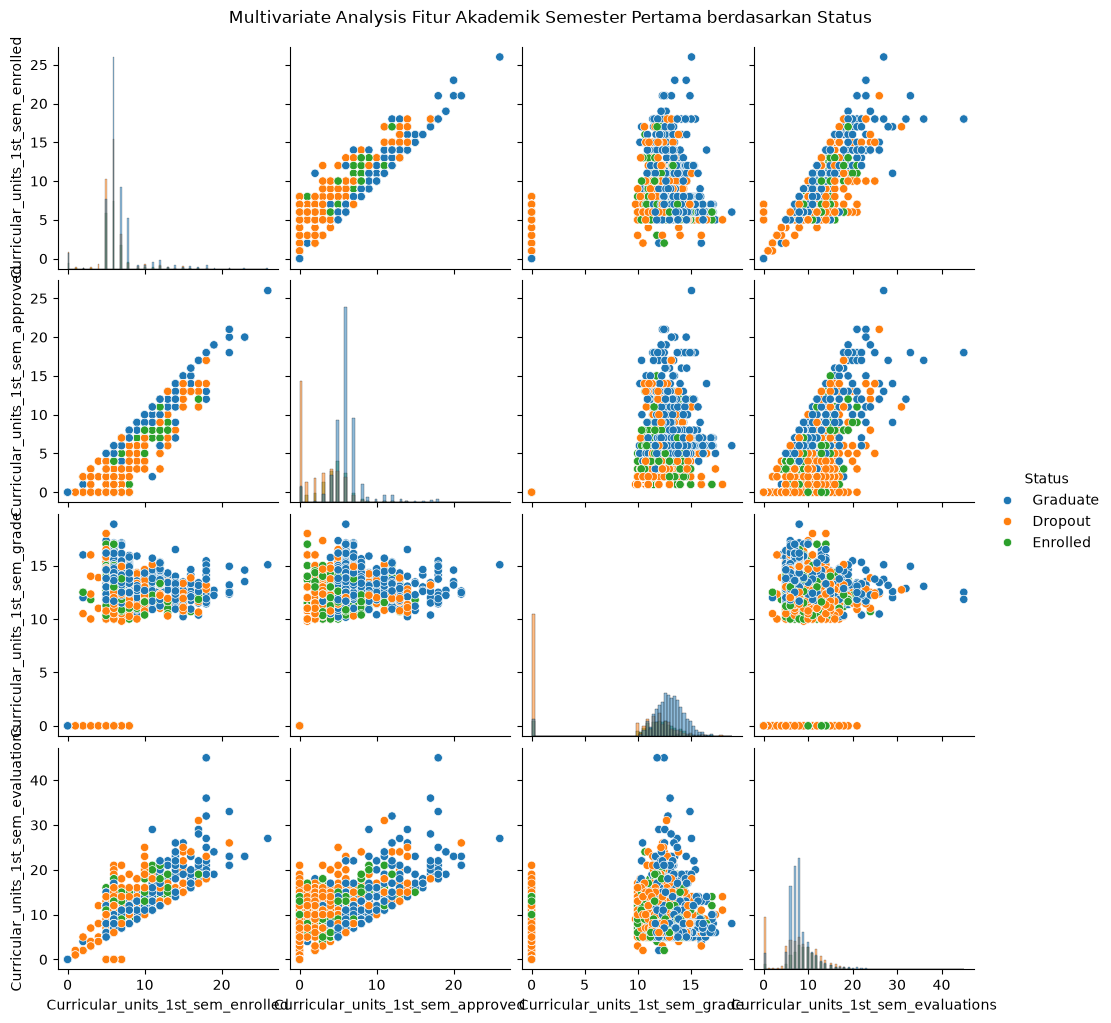

In [30]:
multivariate_features = [
    'Curricular_units_1st_sem_enrolled',
    'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade',
    'Curricular_units_1st_sem_evaluations',
    'Status'
]

sns.pairplot(
    df[multivariate_features],
    hue='Status',
    hue_order=['Graduate', 'Dropout', 'Enrolled'],
    diag_kind='hist'
)

plt.suptitle(
    'Multivariate Analysis Fitur Akademik Semester Pertama berdasarkan Status',
    y=1.02
)

plt.show()

#### Interpretasi

Berdasarkan hasil Multivariate Analysis menggunakan pairplot, terlihat adanya hubungan antar beberapa fitur akademik semester pertama dan perbedaan pola distribusi berdasarkan `Status`.

Hubungan antara `Curricular_units_1st_sem_enrolled` dan `Curricular_units_1st_sem_approved` terlihat cukup kuat dan membentuk pola yang cenderung meningkat. Mahasiswa yang mengambil lebih banyak unit pada semester pertama cenderung memiliki jumlah unit yang disetujui lebih tinggi. Pola ini terlihat pada ketiga kelompok status, meskipun posisi dan penyebarannya berbeda.

Hubungan antara `Curricular_units_1st_sem_enrolled` dan `Curricular_units_1st_sem_evaluations` juga menunjukkan pola positif. Semakin banyak unit yang diambil, secara umum jumlah evaluasi yang dilakukan juga cenderung meningkat.

Pada hubungan `Curricular_units_1st_sem_approved` dengan `Curricular_units_1st_sem_evaluations`, terlihat pola positif. Mahasiswa dengan jumlah unit yang disetujui lebih tinggi cenderung memiliki jumlah evaluasi yang lebih tinggi.

Hubungan `Curricular_units_1st_sem_approved` dengan `Curricular_units_1st_sem_grade` juga menunjukkan pola positif. Kelompok `Graduate` terlihat lebih banyak berada pada kombinasi jumlah unit yang disetujui dan nilai akademik yang lebih tinggi, sedangkan titik `Dropout` lebih banyak ditemukan pada nilai dan jumlah unit yang lebih rendah.

Pada hubungan `Curricular_units_1st_sem_enrolled` dengan `Curricular_units_1st_sem_grade`, pola hubungan terlihat lebih menyebar dibandingkan hubungan antar jumlah unit. Meskipun demikian, terdapat kecenderungan bahwa mahasiswa dengan jumlah unit yang diambil lebih tinggi memiliki nilai akademik yang berada pada rentang tertentu.

Hubungan antara `Curricular_units_1st_sem_grade` dan `Curricular_units_1st_sem_evaluations` menunjukkan pola yang lebih tersebar. Ketiga status memiliki titik observasi pada sebagian besar rentang nilai, sehingga terdapat tumpang tindih antar kelompok.

Distribusi pada diagonal pairplot menunjukkan bahwa beberapa fitur memiliki pola distribusi yang berbeda antar status. `Curricular_units_1st_sem_grade` memperlihatkan konsentrasi nilai yang berbeda pada masing-masing kelompok, sedangkan beberapa fitur jumlah unit memiliki distribusi yang lebih terkonsentrasi pada nilai tertentu.

Secara keseluruhan, Multivariate Analysis menunjukkan bahwa fitur-fitur akademik semester pertama memiliki hubungan yang saling berkaitan, terutama antara jumlah unit yang diambil, jumlah unit yang disetujui, dan jumlah evaluasi. Selain itu, terdapat pola perbedaan distribusi antara `Graduate`, `Dropout`, dan `Enrolled`, terutama pada kombinasi fitur yang berkaitan dengan aktivitas dan hasil akademik semester pertama.

Namun, terdapat pula tumpang tindih antar kelompok `Status`. Oleh karena itu, tidak semua mahasiswa dapat dibedakan hanya berdasarkan satu atau dua fitur. Kondisi ini mendukung penggunaan beberapa fitur secara bersamaan dalam proses pemodelan machine learning.

### Kesimpulan EDA

#### 

Berdasarkan hasil Exploratory Data Analysis, dataset mahasiswa memiliki tiga kategori `Status`, yaitu `Graduate`, `Dropout`, dan `Enrolled`, dengan jumlah data yang berbeda pada setiap kategori. `Graduate` merupakan kategori dengan jumlah terbesar, sedangkan `Enrolled` memiliki jumlah paling sedikit.

Pada analisis univariat, beberapa variabel menunjukkan distribusi yang tidak merata. Variabel kategorikal seperti `Nacionality`, `Previous_qualification`, dan `Educational_special_needs` memiliki kategori yang sangat dominan, sementara beberapa kategori lainnya memiliki jumlah observasi yang relatif sedikit.

Pada analisis bivariat, beberapa fitur numerik menunjukkan perbedaan distribusi antar status mahasiswa. Fitur akademik semester pertama, terutama `Curricular_units_1st_sem_approved` dan `Curricular_units_1st_sem_grade`, memperlihatkan perbedaan distribusi yang cukup terlihat antara `Graduate`, `Dropout`, dan `Enrolled`. `Age_at_enrollment` juga menunjukkan perbedaan distribusi antar kelompok status.

Pada fitur kategorikal, beberapa variabel seperti `Application_mode`, `Course`, `Gender`, `Debtor`, `Tuition_fees_up_to_date`, `Scholarship_holder`, dan `Displaced` menunjukkan perbedaan komposisi status pada kategori-kategorinya. Namun, kategori dengan jumlah observasi yang sangat kecil perlu ditafsirkan secara hati-hati.

Hasil analisis korelasi menunjukkan bahwa beberapa fitur akademik semester pertama memiliki hubungan yang cukup kuat satu sama lain. Hubungan yang cukup tinggi terlihat antara jumlah unit yang diambil, unit yang dikreditkan, unit yang disetujui, jumlah evaluasi, dan nilai akademik.

Hasil Multivariate Analysis juga menunjukkan bahwa fitur akademik semester pertama memiliki pola hubungan yang saling berkaitan dan terdapat perbedaan distribusi pada beberapa kombinasi fitur berdasarkan `Status`. Meskipun demikian, terdapat tumpang tindih antar kelompok sehingga diperlukan kombinasi beberapa fitur untuk melakukan prediksi status mahasiswa.

Secara keseluruhan, hasil EDA menunjukkan bahwa karakteristik akademik semester pertama, karakteristik pendaftaran, demografi, serta kondisi finansial mahasiswa memiliki pola yang berbeda pada masing-masing status. Temuan ini akan digunakan sebagai dasar dalam membangun model machine learning untuk memprediksi `Status` mahasiswa.

## Modeling

### Logistic Regression

In [31]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_processed, y_train)

y_pred_logistic = logistic_model.predict(X_test_processed)

print("Logistic Regression berhasil dilatih.")

Logistic Regression berhasil dilatih.


#### Interpretasi

Model Logistic Regression berhasil dilatih menggunakan data training yang terdiri dari **3.539 data mahasiswa** dan fitur hasil preprocessing sebanyak **245 fitur**.

Model kemudian digunakan untuk menghasilkan prediksi terhadap **885 data mahasiswa** pada data testing. Prediksi tersebut akan digunakan pada tahap evaluasi untuk mengetahui kemampuan model dalam mengklasifikasikan mahasiswa ke dalam tiga kategori `Graduate`, `Dropout`, dan `Enrolled`.

Tahap berikutnya adalah mengevaluasi hasil prediksi Logistic Regression menggunakan beberapa metrik klasifikasi.

In [32]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)

print("Accuracy Logistic Regression:", accuracy_logistic)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Accuracy Logistic Regression: 0.7401129943502824

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.79      0.75      0.77       284
    Enrolled       0.45      0.30      0.36       159
    Graduate       0.78      0.89      0.83       442

    accuracy                           0.74       885
   macro avg       0.67      0.65      0.65       885
weighted avg       0.72      0.74      0.73       885



#### Interpretasi

Berdasarkan hasil evaluasi, model Logistic Regression memperoleh nilai **accuracy sebesar 74,01%** pada data testing yang terdiri dari 885 mahasiswa. Artinya, sekitar 74% prediksi model sesuai dengan status aktual mahasiswa pada data testing.

Pada kelas `Dropout`, model memperoleh precision sebesar **0,79**, recall **0,75**, dan F1-score **0,77**. Hasil ini menunjukkan bahwa model mampu mengidentifikasi mahasiswa dengan status `Dropout` dengan performa yang relatif baik dibandingkan kelas `Enrolled`.

Pada kelas `Graduate`, model memperoleh precision sebesar **0,78**, recall sebesar **0,89**, dan F1-score sebesar **0,83**. Nilai recall yang tinggi menunjukkan bahwa sebagian besar mahasiswa yang sebenarnya berstatus `Graduate` berhasil dikenali oleh model.

Sementara itu, performa model pada kelas `Enrolled` lebih rendah. Precision yang diperoleh sebesar **0,45**, recall **0,30**, dan F1-score **0,36**. Nilai recall tersebut menunjukkan bahwa model masih kesulitan mengenali mahasiswa yang sebenarnya berstatus `Enrolled`.

Nilai **macro average F1-score sebesar 0,65** menunjukkan bahwa ketika performa ketiga kelas diberi bobot yang sama, performa model lebih rendah dibandingkan weighted average F1-score yang mencapai **0,73**. Perbedaan tersebut terutama dipengaruhi oleh performa yang lebih rendah pada kelas `Enrolled`.

Secara keseluruhan, Logistic Regression mampu melakukan klasifikasi tiga status mahasiswa dengan accuracy sebesar 74,01%, tetapi performanya belum merata pada seluruh kelas. Oleh karena itu, diperlukan evaluasi lebih lanjut menggunakan confusion matrix untuk melihat pola kesalahan prediksi antar kelas.

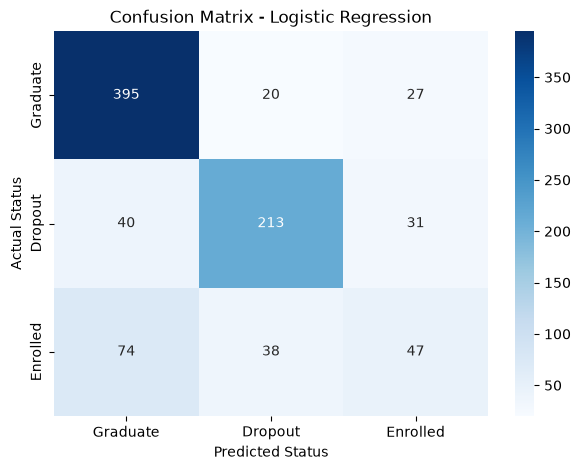

In [33]:
cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic,
    labels=['Graduate', 'Dropout', 'Enrolled']
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Graduate', 'Dropout', 'Enrolled'],
    yticklabels=['Graduate', 'Dropout', 'Enrolled']
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Status')
plt.ylabel('Actual Status')
plt.show()

#### Interpretasi

Berdasarkan confusion matrix Logistic Regression, terdapat **395 mahasiswa Graduate** yang berhasil diprediksi sebagai `Graduate`, **213 mahasiswa Dropout** yang berhasil diprediksi sebagai `Dropout`, dan **47 mahasiswa Enrolled** yang berhasil diprediksi sebagai `Enrolled`.

Pada kelas `Graduate`, terdapat **395 prediksi yang benar**. Sebanyak **20 mahasiswa Graduate** diprediksi sebagai `Dropout`, sedangkan **27 mahasiswa Graduate** diprediksi sebagai `Enrolled`.

Pada kelas `Dropout`, sebanyak **213 mahasiswa** berhasil diklasifikasikan dengan benar sebagai `Dropout`. Sementara itu, **40 mahasiswa Dropout** diprediksi sebagai `Graduate` dan **31 mahasiswa Dropout** diprediksi sebagai `Enrolled`.

Pada kelas `Enrolled`, sebanyak **47 mahasiswa** berhasil diprediksi dengan benar. Namun, terdapat **74 mahasiswa Enrolled** yang diprediksi sebagai `Graduate` dan **38 mahasiswa Enrolled** yang diprediksi sebagai `Dropout`. Kesalahan prediksi pada kelas `Enrolled` ini merupakan salah satu penyebab rendahnya recall kelas tersebut.

Secara keseluruhan, confusion matrix menunjukkan bahwa Logistic Regression paling banyak menghasilkan prediksi yang benar pada kelas `Graduate` dan `Dropout`. Sebaliknya, kelas `Enrolled` masih lebih sulit dibedakan oleh model, terutama karena cukup banyak mahasiswa dengan status `Enrolled` yang diprediksi sebagai `Graduate`.

### Decision Tree

In [34]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train_processed, y_train)

y_pred_tree = decision_tree_model.predict(X_test_processed)

print("Decision Tree berhasil dilatih.")

Decision Tree berhasil dilatih.


#### Interpretasi

Model Decision Tree berhasil dilatih menggunakan data training yang terdiri dari **3.539 data mahasiswa** dengan **245 fitur hasil preprocessing**.

Model kemudian digunakan untuk menghasilkan prediksi terhadap **885 data mahasiswa** pada data testing. Prediksi tersebut akan digunakan untuk mengevaluasi kemampuan Decision Tree dalam mengklasifikasikan mahasiswa ke dalam tiga kategori `Graduate`, `Dropout`, dan `Enrolled`.

Selanjutnya, performa Decision Tree akan dievaluasi menggunakan accuracy, precision, recall, dan F1-score.

In [35]:
accuracy_tree = accuracy_score(y_test, y_pred_tree)

print("Accuracy Decision Tree:", accuracy_tree)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

Accuracy Decision Tree: 0.6576271186440678

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.65      0.63      0.64       284
    Enrolled       0.36      0.39      0.37       159
    Graduate       0.79      0.77      0.78       442

    accuracy                           0.66       885
   macro avg       0.60      0.60      0.60       885
weighted avg       0.66      0.66      0.66       885



#### Interpretasi

Berdasarkan hasil evaluasi, model Decision Tree memperoleh nilai **accuracy sebesar 65,73%** pada data testing yang terdiri dari 885 mahasiswa. Artinya, sekitar 65,73% prediksi model sesuai dengan status aktual mahasiswa.

Pada kelas `Dropout`, model memperoleh precision sebesar **0,65**, recall sebesar **0,63**, dan F1-score sebesar **0,64**. Hasil tersebut menunjukkan bahwa model mampu mengenali sebagian mahasiswa yang berstatus `Dropout`, meskipun masih terdapat kesalahan klasifikasi.

Pada kelas `Graduate`, model memperoleh precision sebesar **0,79**, recall sebesar **0,77**, dan F1-score sebesar **0,78**. Performa pada kelas ini lebih tinggi dibandingkan kelas `Dropout` dan `Enrolled`.

Sementara itu, kelas `Enrolled` memiliki performa paling rendah dengan precision sebesar **0,36**, recall sebesar **0,39**, dan F1-score sebesar **0,37**. Hal ini menunjukkan bahwa Decision Tree masih mengalami kesulitan dalam membedakan mahasiswa dengan status `Enrolled` dari kelas lainnya.

Nilai **macro average F1-score sebesar 0,60** menunjukkan rata-rata performa ketiga kelas ketika masing-masing kelas diberikan bobot yang sama. Sementara itu, weighted average F1-score sebesar **0,66** menunjukkan performa dengan mempertimbangkan jumlah data pada setiap kelas.

Secara keseluruhan, Decision Tree menghasilkan accuracy sebesar 65,73% dan performa yang belum merata pada ketiga kelas. Kelas `Graduate` memiliki F1-score tertinggi, sedangkan kelas `Enrolled` memiliki F1-score terendah. Hasil ini selanjutnya akan dilengkapi dengan confusion matrix untuk melihat pola kesalahan prediksi secara lebih rinci.

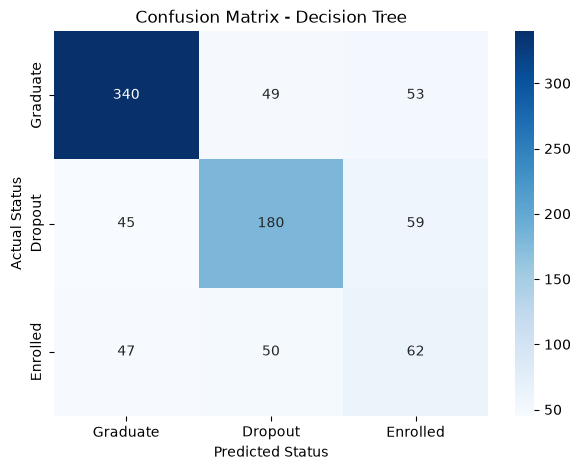

In [36]:
cm_tree = confusion_matrix(
    y_test,
    y_pred_tree,
    labels=['Graduate', 'Dropout', 'Enrolled']
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Graduate', 'Dropout', 'Enrolled'],
    yticklabels=['Graduate', 'Dropout', 'Enrolled']
)

plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted Status')
plt.ylabel('Actual Status')
plt.show()

#### Interpretasi

Berdasarkan confusion matrix Decision Tree, terdapat **340 mahasiswa Graduate** yang berhasil diprediksi sebagai `Graduate`, **180 mahasiswa Dropout** yang berhasil diprediksi sebagai `Dropout`, dan **62 mahasiswa Enrolled** yang berhasil diprediksi sebagai `Enrolled`.

Pada kelas `Graduate`, sebanyak **340 mahasiswa** berhasil diklasifikasikan dengan benar. Sementara itu, **49 mahasiswa Graduate** diprediksi sebagai `Dropout` dan **53 mahasiswa Graduate** diprediksi sebagai `Enrolled`.

Pada kelas `Dropout`, sebanyak **180 mahasiswa** berhasil diprediksi dengan benar sebagai `Dropout`. Sebanyak **45 mahasiswa Dropout** diprediksi sebagai `Graduate`, sedangkan **59 mahasiswa Dropout** diprediksi sebagai `Enrolled`.

Pada kelas `Enrolled`, sebanyak **62 mahasiswa** berhasil diprediksi dengan benar. Namun, terdapat **47 mahasiswa Enrolled** yang diprediksi sebagai `Graduate` dan **50 mahasiswa Enrolled** yang diprediksi sebagai `Dropout`.

Secara keseluruhan, Decision Tree menghasilkan jumlah prediksi benar terbesar pada kelas `Graduate`, sedangkan jumlah prediksi benar pada kelas `Enrolled` relatif lebih rendah. Pola ini sesuai dengan classification report sebelumnya, di mana kelas `Enrolled` memiliki recall sebesar **0,39** dan F1-score sebesar **0,37**.

Hasil confusion matrix menunjukkan bahwa Decision Tree masih mengalami kesulitan membedakan kelas `Enrolled` dengan dua kelas lainnya. Hasil ini akan menjadi salah satu bahan perbandingan ketika model berikutnya, yaitu Random Forest, dievaluasi.

### Random Forest

In [37]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train_processed, y_train)

y_pred_rf = random_forest_model.predict(X_test_processed)

print("Random Forest berhasil dilatih.")

Random Forest berhasil dilatih.


#### Interpretasi

Model Random Forest berhasil dilatih menggunakan data training yang terdiri dari **3.539 data mahasiswa** dengan **245 fitur hasil preprocessing**.

Model kemudian digunakan untuk menghasilkan prediksi terhadap **885 data mahasiswa** pada data testing. Prediksi tersebut akan digunakan untuk mengevaluasi kemampuan Random Forest dalam mengklasifikasikan mahasiswa ke dalam tiga kategori `Graduate`, `Dropout`, dan `Enrolled`.

Selanjutnya, performa Random Forest akan dievaluasi menggunakan accuracy, precision, recall, dan F1-score.

In [38]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy Random Forest:", accuracy_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy Random Forest: 0.7141242937853107

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.74      0.71      0.73       284
    Enrolled       0.40      0.17      0.24       159
    Graduate       0.74      0.91      0.82       442

    accuracy                           0.71       885
   macro avg       0.63      0.60      0.59       885
weighted avg       0.68      0.71      0.68       885



#### Interpretasi

Berdasarkan hasil evaluasi, model Random Forest memperoleh nilai **accuracy sebesar 71,41%** pada data testing yang terdiri dari 885 mahasiswa. Artinya, sekitar 71,41% prediksi model sesuai dengan status aktual mahasiswa.

Pada kelas `Dropout`, model memperoleh precision sebesar **0,74**, recall sebesar **0,71**, dan F1-score sebesar **0,73**. Hasil tersebut menunjukkan bahwa Random Forest mampu mengenali sebagian besar mahasiswa yang berstatus `Dropout`, meskipun masih terdapat beberapa kesalahan klasifikasi.

Pada kelas `Graduate`, model memperoleh precision sebesar **0,74**, recall sebesar **0,91**, dan F1-score sebesar **0,82**. Nilai recall sebesar 0,91 menunjukkan bahwa sebagian besar mahasiswa yang sebenarnya berstatus `Graduate` berhasil dikenali oleh model.

Sementara itu, kelas `Enrolled` memiliki performa paling rendah. Model memperoleh precision sebesar **0,40**, recall sebesar **0,17**, dan F1-score sebesar **0,24**. Nilai recall tersebut menunjukkan bahwa sebagian besar mahasiswa yang sebenarnya berstatus `Enrolled` masih diprediksi sebagai kelas lainnya.

Nilai **macro average F1-score sebesar 0,59** menunjukkan rata-rata performa ketiga kelas ketika setiap kelas diberikan bobot yang sama. Sementara itu, weighted average F1-score sebesar **0,68** mempertimbangkan jumlah observasi pada masing-masing kelas.

Secara keseluruhan, Random Forest mampu menghasilkan accuracy sebesar 71,41%, dengan performa yang lebih tinggi pada kelas `Graduate` dan `Dropout` dibandingkan kelas `Enrolled`. Performa pada kelas `Enrolled` masih menjadi tantangan utama dan perlu diperhatikan ketika membandingkan ketiga model.

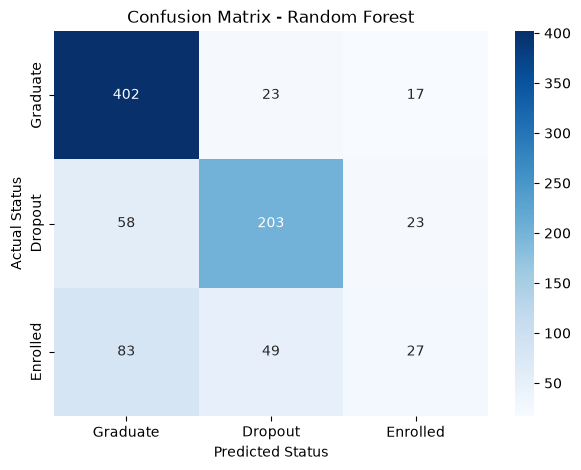

In [39]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=['Graduate', 'Dropout', 'Enrolled']
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Graduate', 'Dropout', 'Enrolled'],
    yticklabels=['Graduate', 'Dropout', 'Enrolled']
)

plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Status')
plt.ylabel('Actual Status')
plt.show()

#### Interpretasi

Berdasarkan confusion matrix Random Forest, terdapat **402 mahasiswa Graduate** yang berhasil diprediksi sebagai `Graduate`, **203 mahasiswa Dropout** yang berhasil diprediksi sebagai `Dropout`, dan **27 mahasiswa Enrolled** yang berhasil diprediksi sebagai `Enrolled`.

Pada kelas `Graduate`, sebanyak **402 mahasiswa** berhasil diklasifikasikan dengan benar. Sementara itu, **23 mahasiswa Graduate** diprediksi sebagai `Dropout` dan **17 mahasiswa Graduate** diprediksi sebagai `Enrolled`.

Pada kelas `Dropout`, sebanyak **203 mahasiswa** berhasil diprediksi dengan benar sebagai `Dropout`. Sebanyak **58 mahasiswa Dropout** diprediksi sebagai `Graduate`, sedangkan **23 mahasiswa Dropout** diprediksi sebagai `Enrolled`.

Pada kelas `Enrolled`, hanya **27 mahasiswa** yang berhasil diprediksi dengan benar. Sementara itu, **83 mahasiswa Enrolled** diprediksi sebagai `Graduate` dan **49 mahasiswa Enrolled** diprediksi sebagai `Dropout`.

Secara keseluruhan, Random Forest menghasilkan jumlah prediksi benar yang cukup tinggi pada kelas `Graduate` dan `Dropout`. Namun, kelas `Enrolled` masih menjadi kelas yang paling sulit dikenali oleh model. Hal ini sesuai dengan hasil classification report sebelumnya, di mana kelas `Enrolled` memiliki recall sebesar **0,17** dan F1-score sebesar **0,24**.

Hasil confusion matrix menunjukkan bahwa sebagian besar kesalahan pada kelas `Enrolled` terjadi ketika mahasiswa dengan status aktual `Enrolled` diprediksi sebagai `Graduate`. Pola kesalahan ini perlu diperhatikan ketika membandingkan performa ketiga model.

## Evaluation

In [40]:
from sklearn.metrics import precision_score, recall_score, f1_score

evaluation_results = {
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_logistic,
        accuracy_tree,
        accuracy_rf
    ],
    'Precision': [
        precision_score(y_test, y_pred_logistic, average='weighted'),
        precision_score(y_test, y_pred_tree, average='weighted'),
        precision_score(y_test, y_pred_rf, average='weighted')
    ],
    'Recall': [
        recall_score(y_test, y_pred_logistic, average='weighted'),
        recall_score(y_test, y_pred_tree, average='weighted'),
        recall_score(y_test, y_pred_rf, average='weighted')
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_logistic, average='weighted'),
        f1_score(y_test, y_pred_tree, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted')
    ],
    'Macro F1-Score': [
        f1_score(y_test, y_pred_logistic, average='macro'),
        f1_score(y_test, y_pred_tree, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro')
    ]
}

evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df

,Model,Accuracy,Precision,Recall,F1-Score,Macro F1-Score
0,Logistic Regression,0.740113,0.720220,0.740113,0.725169,0.651444
1,Decision Tree,0.657627,0.664126,0.657627,0.660673,0.596612
2,Random Forest,0.714124,0.679034,0.714124,0.683660,0.593826


#### Interpretasi

Berdasarkan hasil perbandingan ketiga model, Logistic Regression memperoleh accuracy sebesar **74,01%**, precision sebesar **72,02%**, recall sebesar **74,01%**, dan F1-score sebesar **72,52%**. Model ini juga memiliki Macro F1-score sebesar **65,14%**.

Decision Tree memperoleh accuracy sebesar **65,76%**, precision sebesar **66,41%**, recall sebesar **65,76%**, dan F1-score sebesar **66,07%**. Macro F1-score yang diperoleh adalah **59,66%**.

Random Forest memperoleh accuracy sebesar **71,41%**, precision sebesar **67,90%**, recall sebesar **71,41%**, dan F1-score sebesar **68,37%**. Macro F1-score yang diperoleh adalah **59,38%**.

Dari hasil tersebut terlihat bahwa ketiga model memiliki performa yang berbeda pada metrik evaluasi. Logistic Regression memiliki nilai accuracy, precision, recall, F1-score, dan Macro F1-score yang lebih tinggi dibandingkan dua model lainnya pada tabel evaluasi ini.

Namun, hasil evaluasi keseluruhan perlu dibaca bersama classification report masing-masing model. Ketiga model sama-sama menunjukkan bahwa kelas `Enrolled` lebih sulit diklasifikasikan dibandingkan `Graduate` dan `Dropout`, sehingga performa rata-rata antar kelas masih dipengaruhi oleh rendahnya performa pada kelas tersebut.

Hasil evaluasi ini akan digunakan sebagai dasar untuk menentukan model yang akan digunakan sebagai final model pada tahap berikutnya.

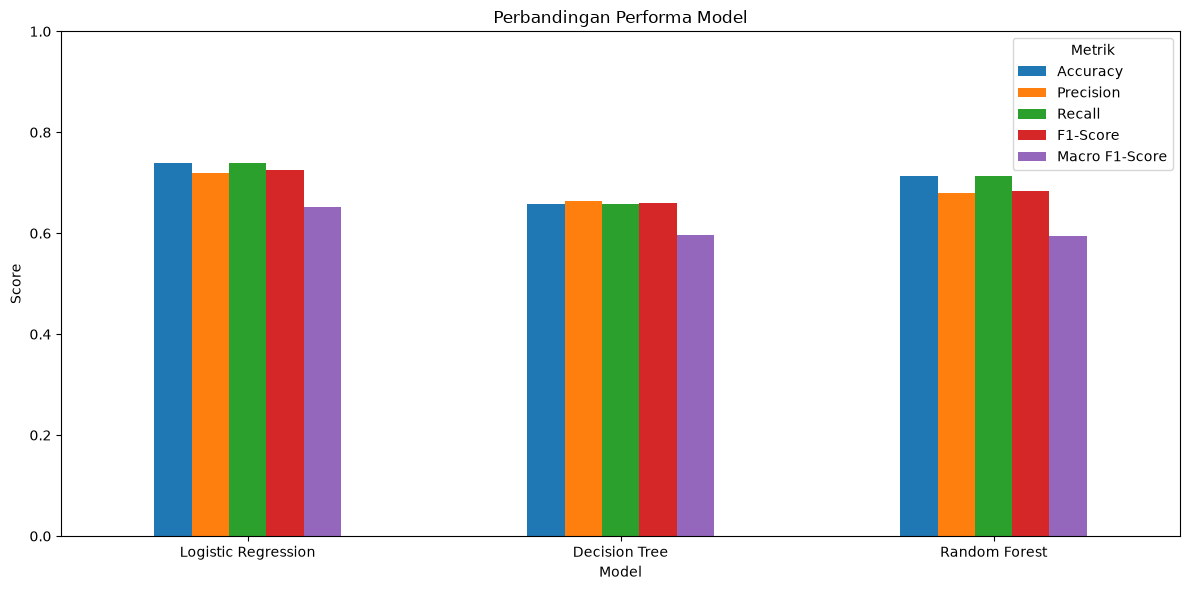

In [41]:
evaluation_plot = evaluation_df.set_index('Model')[
    ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Macro F1-Score']
]

evaluation_plot.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Perbandingan Performa Model')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title='Metrik')
plt.tight_layout()
plt.show()

#### Interpretasi

Berdasarkan visualisasi perbandingan performa model, terlihat bahwa ketiga model memiliki tingkat performa yang berbeda pada seluruh metrik evaluasi yang digunakan.

`Logistic Regression` memperoleh nilai tertinggi pada seluruh metrik yang dibandingkan, yaitu accuracy sebesar **74,01%**, precision sebesar **72,02%**, recall sebesar **74,01%**, F1-score sebesar **72,52%**, dan Macro F1-score sebesar **65,14%**.

`Random Forest` memiliki accuracy sebesar **71,41%**, precision sebesar **67,90%**, recall sebesar **71,41%**, F1-score sebesar **68,37%**, dan Macro F1-score sebesar **59,38%**. Performa model ini berada di bawah Logistic Regression pada seluruh metrik pada tabel evaluasi.

`Decision Tree` memperoleh accuracy sebesar **65,76%**, precision sebesar **66,41%**, recall sebesar **65,76%**, F1-score sebesar **66,07%**, dan Macro F1-score sebesar **59,66%**.

Berdasarkan perbandingan tersebut, Logistic Regression menghasilkan performa evaluasi tertinggi pada dataset testing untuk seluruh metrik yang digunakan. Meskipun demikian, ketiga model masih menunjukkan tantangan dalam mengenali kelas `Enrolled`, sebagaimana terlihat pada classification report dan confusion matrix masing-masing model.

Hasil perbandingan ini menjadi dasar untuk menggunakan Logistic Regression sebagai model final yang akan digunakan pada tahap selanjutnya.

### Logistic Regression sebagai Final Model

Berdasarkan hasil evaluasi terhadap Logistic Regression, Decision Tree, dan Random Forest, Logistic Regression digunakan sebagai final model karena memperoleh nilai tertinggi pada accuracy, precision, recall, F1-score, dan Macro F1-score pada data testing.

Model ini akan digunakan pada tahap selanjutnya untuk membuat sistem prediksi status mahasiswa.

In [42]:
from sklearn.pipeline import Pipeline

final_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

final_model.fit(X_train, y_train)

print("Final model berhasil dilatih.")

Final model berhasil dilatih.


## Menyimpan Model

#### 
Final model disimpan dalam format `.pkl` menggunakan library `joblib`. File tersebut berisi preprocessing dan Logistic Regression dalam satu pipeline sehingga dapat digunakan kembali untuk melakukan prediksi terhadap data mahasiswa baru.

In [43]:
import joblib

model_path = 'model_dropout.pkl'

joblib.dump(final_model, model_path)

print(f"Final model berhasil disimpan sebagai: {model_path}")

Final model berhasil disimpan sebagai: model_dropout.pkl


In [44]:
dashboard_data = df.copy()

dashboard_data.to_csv(
    "dashboard_data.csv",
    index=False
)

print("dashboard_data.csv berhasil dibuat.")
print("Jumlah data:", len(dashboard_data))

dashboard_data.csv berhasil dibuat.
Jumlah data: 4424
